In [1]:
import numpy as np
import healpy as hp

import matplotlib
from matplotlib import pyplot as plt

from scipy import stats
import matplotlib.gridspec as gridspec
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
from matplotlib import cm
from scipy.optimize import minimize
from astropy.cosmology import Planck18
from dynesty import NestedSampler
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
from astropy.coordinates import SkyCoord
from healpy.newvisufunc import projview
from scipy import linalg
from scipy.special import gamma

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using step-function HOD
## Define parameters

In [3]:
G_hi = 20.5

In [4]:
nthreads = 18

In [5]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.6])
z_array = range(len(z_bins)-1)
mask = 0.5

In [6]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value, m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

In [7]:
Delta = 200
delta_c = 1.686

In [8]:
hmf = ccl.halos.MassFuncTinker10()

In [9]:
NSIDE = 64

In [10]:
M_max = 15

## Define functions

In [11]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [12]:
def b_qso(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

In [13]:
def nu(M, delta_c = delta_c, a = 1, cosmo = cosmo_planck18):
    
    sigma = cosmo.sigmaM(M, a = a)
   
    return delta_c/sigma

In [14]:
def n_g_theory(bins, n_total, a = 1, cosmo = cosmo_planck18, hmf = hmf, recenter = True):

    if recenter == True:
        bins = quaia.recenter(bins)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3
    n_g = nm/(bins*np.log(10))*n_total
    n_g[np.isnan(n_g)]=0
    
    return n_g, nm

def bias(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter)
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
    n_g = np.trapz(n_g, bins)
    dn_dm = nm/(bins*np.log(10))

    b1_E_tinker = b1_E_func(nu(bins, a = a, cosmo = cosmo), mod = mod)

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    return bias_function(n_g, integrand, b1_E_tinker, bins, recenter = recenter), n_g

In [15]:
def b1_E_func(nu, Delta = Delta, delta_c = delta_c, mod = False):

    delta_c = 1.686
    
    if mod == False:
        y = np.log10(Delta)
        A =  1.0+0.24*y*np.exp(-(4/y)**4)
        a = 0.44*y-0.88
        B = 0.183
        b =  1.5
        C = 0.019+0.107*y+0.19*np.exp(-(4/y)**4)
        c = 2.4
        
    else:
        A =  1.0
        a = 0.0906
        B = -4.5002
        b =  2.1419
        C = 4.9148
        c = 2.1419
        
    return 1-A*nu**a/(nu**a+delta_c**a)+B*nu**b+C*nu**c # Jose et al
    
def bias_function(n_g, integrand, b, bins, recenter = True):
    
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
        
    return 1/n_g*np.trapz(integrand*b, bins)

In [16]:
def cf_2h(bins, n_m, a, cosmo, cf_matter, recenter = True):
    
    b_q, n_g = bias(bins, n_m, a, cosmo, recenter = recenter)
    return b_q**2*cf_matter, b_q

In [17]:
def M(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True, hmf = hmf):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter, hmf = hmf)
    if recenter == True:
        n_g = np.trapz(n_g, quaia.recenter(bins))
        dm = np.diff(bins) 
        dn_dm = nm/(quaia.recenter(bins)*np.log(10))
    else:
        n_g = np.trapz(n_g, bins)
        dn_dm = nm/(bins*np.log(10))

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    if recenter == True:
        return bias_function(n_g, integrand, quaia.recenter(bins), bins, recenter = recenter), n_g
    else:
        return bias_function(n_g, integrand, bins, bins, recenter = recenter), n_g

In [18]:
def HOD(bins, M_min, fduty):

    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=M_min]=fduty

    return n_m

In [19]:
def n_DM(cosmo, a, M_min, hmf = hmf, M_max = M_max, N = 79): #16.8
    
    bins = np.logspace(M_min, M_max, N)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 #/u.Mpc**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.trapz(dn_dm, bins)

# Implement halo model
## Plot HOD: $\langle N(M) \rangle = \begin{cases}f_{duty} & M\geq M_{min} \\ 0 & M<M_{min}\end{cases}$
### At fixed $f_{duty}$ and $M_{min}$

In [20]:
bins = np.logspace(9, M_max, 79)

In [21]:
M_min_array_old = [12.86, 12.74, 12.79, 12.82]
M_min_array = [11.94, 11.98, 11.97, 12.07]

In [22]:
fduty_old = [0.018, 0.022, 0.056, 0.071]
fduty = [0.002, 0.002, 0.003, 0.002]
n_m_array = []
for i in z_array:        
    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=10**M_min_array[i]]=fduty[i]
    n_m_array.append(n_m)

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_103182/3618045427.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))
/tmp/ipykernel_103182/3618045427.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M (M_\odot)$')


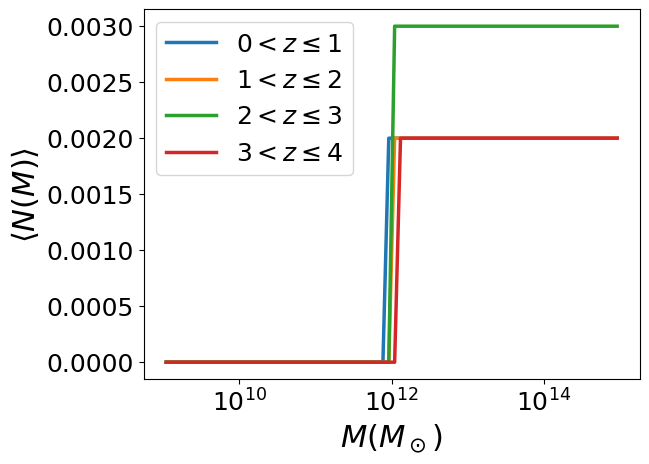

In [23]:
for i in z_array:
        
    plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))

plt.xscale('log')
plt.xlabel('$M (M_\odot)$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.legend()
plt.show()

In [24]:
n_m_array, bins_M_min = [], []
for i in z_array:   
    bins_i = np.logspace(M_min_array[i], M_max, 79)
    n_m=np.ones(np.shape(bins_i))*fduty[i]
    n_m_array.append(n_m)
    bins_M_min.append(bins_i)

In [25]:
n_m_array_2D = []
for i in z_array:

    n_m_array_2D.append([])
    
    for j in range(len(bins)):
        
        n_m=np.ones(np.shape(bins))*fduty[i]
        n_m_array_2D[i].append(n_m)

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{qq}}(s)}{\xi^{(r)}_\mathrm{mm}(r)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$
### Use a 50th percentile mask

In [26]:
bins_M_min_array = [np.logspace(np.log10(bins[j]), M_max, 79) for j in range(len(bins))]

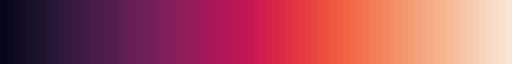

In [27]:
cmap = sns.color_palette("rocket", n_colors = len(bins))
palette = matplotlib.colors.ListedColormap(cmap)
palette

# Calculate derived parameters
## Plot b(z)

In [28]:
def b_eboss(z):
    
    return 0.278*((1+z)**2-6.565) + 2.393

def b_quaia(b_0, a, cosmo = cosmo_planck18): #quaia):
    
    return b_0/ccl.growth_factor(cosmo, a)

In [29]:
b_cf20 = np.load('../results/b_cf20_planck18.npy')
b_wp20 = np.load('../results/b_wp20_planck18.npy')

# Calculate number density as $n_q \approx \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle$

In [30]:
tab_datahi_mask_zbins, selfunc_hi_bins = [], []
for j in z_array:
    
    tab_datahi_mask_zbin0, _, _, _, _, _, selfunc_hi_bin0, _, pixel_indices_datahi_bin0 = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)
    tab_datahi_mask_zbins.append(tab_datahi_mask_zbin0['redshift_quaia'])
    selfunc_hi_bins.append(selfunc_hi_bin0)

0.6894778799187598
Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0: 0.31              224099 vs 324336
0.6998052038245415
Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0: 0.28              464321 vs 648196
0.7010382664423291
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0: 0.25              214535 vs 286508
0.7686898940836221
Pixels masked by MC but not already by selfunc: 352
G20.5_zmin3.0zmax4.6: 0.22              28576 vs 36458


In [31]:
LMC = SkyCoord(['05 23 34.6 -69 45 22'], unit=(u.hourangle, u.deg)) #https://simbad.u-strasbg.fr/simbad/sim-id?Ident=Large+Magellanic+Cloud

In [32]:
LMC_radius = 9*u.deg

In [33]:
SMC = SkyCoord(['00 52 38.0 -72 48 01'], unit=(u.hourangle, u.deg)) # https://simbad.u-strasbg.fr/simbad/sim-id?Ident=small+Magellanic+Cloud

In [34]:
SMC_radius = 5*u.deg

In [35]:
n_q, n_q_err, V_eff, N_q = [], [], [], []

for j in z_array:
    
    N = len(tab_datahi_mask_zbins[j])
    theta, phi = hp.pix2ang(NSIDE, range(len(selfunc_hi_bins[j])), lonlat=True)
    c = SkyCoord(ra=theta*u.degree, dec=phi*u.degree)
    LMC_idx, _, _, _ = SkyCoord.search_around_sky(LMC, c, LMC_radius)
    SMC_idx, _, _, _ = SkyCoord.search_around_sky(SMC, c, SMC_radius)
    MC_idx = np.append(LMC_idx,SMC_idx)
    MC_mask = np.full_like(range(len(selfunc_hi_bins[j])), True, dtype = bool)
    MC_mask[MC_idx] = False
    cp = np.percentile(selfunc_hi_bins[j][MC_mask], mask*100)
    selfunc_mask = selfunc_hi_bins[j]>=cp
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][selfunc_mask & MC_mask]*hp.nside2pixarea(NSIDE))
    print(f_sky) # f_sky)
    V = f_sky*(Planck18.comoving_volume(z_bins[j+1])-Planck18.comoving_volume(z_bins[j]))*Planck18.h**3/u.h**3
    N_q.append(N)
    n_q.append(N/V.value)
    n_q_err.append(np.sqrt(N)/V.value) # Poisson error
    V_eff.append(V)
    
n_q

0.3815553400077859
0.3990266387789277
0.42567567827451197
0.43715916212910605


[1.1562053955390066e-05,
 8.122737301033735e-06,
 3.0936220453800634e-06,
 2.72364137384074e-07]

In [36]:
fduty_err_hi = 0.002, 0.001, 0.008, 0.077
fduty_err_lo = 0.002, 0.001, 0.007, 0.034

In [37]:
def n_q_theory_err(n_dm, fduty_err, M_min, a, M_min_err, hmf = hmf, cosmo = cosmo_planck18): #quaia):
    
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.sqrt(n_dm**2*fduty_err**2+(fduty_err*hmf(cosmo, 10**M_min, a))**2*M_min_err**2)

## Limit scales to $30\geq s \geq 80h^{-1}$ Mpc

In [38]:
# Create the bins array
rmin = 30 #-delta_min*offset # 0.1 # start higher # 1.4 # 30
rmax = 180 #80 #+delta_max*offset # 200
nbins = 30 #10 #int((rmax-rmin)/offset)
rbins_chi2 = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
rbins_chi2, quaia.recenter(rbins_chi2), np.diff(quaia.recenter(rbins_chi2))

(array([ 30.,  35.,  40.,  45.,  50.,  55.,  60.,  65.,  70.,  75.,  80.,
         85.,  90.,  95., 100., 105., 110., 115., 120., 125., 130., 135.,
        140., 145., 150., 155., 160., 165., 170., 175., 180.]),
 array([ 32.5,  37.5,  42.5,  47.5,  52.5,  57.5,  62.5,  67.5,  72.5,
         77.5,  82.5,  87.5,  92.5,  97.5, 102.5, 107.5, 112.5, 117.5,
        122.5, 127.5, 132.5, 137.5, 142.5, 147.5, 152.5, 157.5, 162.5,
        167.5, 172.5, 177.5]),
 array([5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.]))

In [39]:
cf_chi2, cf_matter_chi2 = [], []
yerr_cf_chi2, b_cf_chi2 = [], []
b_cf_q_chi2 = []
a_zbin = []
H0 = Planck18.H0 # cosmo_planck18['H0'] * u.km/u.s/u.Mpc
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins_chi2, Om0 = Planck18.Om0, h = Planck18.h, error = True)
    cf_chi2.append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)
    a_zbin.append(a)

    # matter correlation function
    rbins_Mpc = (quaia.recenter(rbins_chi2)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmo_planck18, r=rbins_Mpc, a=a)
    cf_matter_chi2.append(cf_matter)

    # effective bias 
    b = np.sqrt(cf/cf_matter)
    b_cf_chi2.append(b)

    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf_chi2.append(yerr)

    # qso bias
    b_cf_q_chi2.append(b_qso(cf, cf_matter, ccl.growth_rate(cosmo_planck18, a)))

0.6894778799187598
Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0: 0.31              224099 vs 324336


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_103182/4246606042.py:29: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_103182/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


0.6998052038245415
Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0: 0.28              464321 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_103182/4246606042.py:29: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_103182/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


0.7010382664423291
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0: 0.25              214535 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_103182/4246606042.py:29: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_103182/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


0.7686898940836221
Pixels masked by MC but not already by selfunc: 352
G20.5_zmin3.0zmax4.6: 0.22              28576 vs 36458


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_103182/4246606042.py:29: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_103182/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


In [40]:
rpmask = (quaia.recenter(rbins_chi2) >= 30) & (quaia.recenter(rbins_chi2) <= 80)

## Compute the maximum number of jackknife regions

In [41]:
N_j = 50

In [42]:
fudge = 2.8
for j in z_array:
    
    # N = len(tab_datahi_mask_zbins[j])
    # theta, phi = hp.pix2ang(NSIDE, range(len(selfunc_hi_bins[j])), lonlat=True)
    # c = SkyCoord(ra=theta*u.degree, dec=phi*u.degree)
    # LMC_idx, _, _, _ = SkyCoord.search_around_sky(LMC, c, LMC_radius)
    # SMC_idx, _, _, _ = SkyCoord.search_around_sky(SMC, c, SMC_radius)
    # MC_idx = np.append(LMC_idx,SMC_idx)
    # MC_mask = np.full_like(range(len(selfunc_hi_bins[j])), True, dtype = bool)
    # MC_mask[MC_idx] = False
    # cp = np.percentile(selfunc_hi_bins[j][MC_mask], mask*100)
    # selfunc_mask = selfunc_hi_bins[j]>=cp
    
    # # calculating N_jk first
    # s_min = Planck18.comoving_transverse_distance(1/a_zbin[j]-1)*2*np.pi*Planck18.h/u.h
    # N_jk_max = np.floor(s_min/(5*rmax*s_min.unit))
    # theta_min = np.ceil(360/N_jk_max)
    
    # calculating theta first
    # s_min = Planck18.comoving_distance(1/a_zbin[j]-1)*Planck18.h/u.h
    # theta_min = np.ceil(np.rad2deg(rmax*s_min.unit/s_min*u.rad))
    # N_jk_max = np.floor(360*u.deg/theta_min)

    r_LOS = Planck18.comoving_distance(1/a_zbin[j]-1)*Planck18.h/u.h
    theta_min = 2*np.arcsin(fudge*rmax*r_LOS.unit/2/r_LOS)
    N_jk_max = np.floor(2*np.pi*theta_min.unit/theta_min)
    
    print('N_j_max:', N_jk_max)
    print('N_q:', int(N_q[j]/N_j))
    print('theta_min:', theta_min)
    print()
    
print('hartlap:', (N_j-nbins-2)/(N_j-1))
print('dodelson:', 1+nbins/N_j)

N_j_max: 22.0
N_q: 4481
theta_min: 0.28276161685934875 rad

N_j_max: 37.0
N_q: 9286
theta_min: 0.16806307649497992 rad

N_j_max: 48.0
N_q: 4290
theta_min: 0.12856751305880829 rad

N_j_max: 56.0
N_q: 571
theta_min: 0.11075550576978664 rad

hartlap: 0.3673469387755102
dodelson: 1.6


In [43]:
21578/N_j

431.56

# Perform nested sampling with dynesty

In [44]:
# Define the dimensionality of our problem.
ndim = 2

## Pick cosmology

In [45]:
cosmo = 'Planck'

In [46]:
N = 50 #40 #20 #65 #50 # 30 #15 #45 #85

In [47]:
# Define our 3-D correlated multivariate normal log-likelihood.
C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
ix_grid = np.ix_(rpmask, rpmask)
hartlap = (N-nbins-2)/(N-1)
print(hartlap)

# check if cov is hermitian and positive definite
if linalg.ishermitian(C) and np.all(np.linalg.eigvals(C) > 0):
    C_factor = linalg.cho_factor(C[ix_grid])
    log_det_C = 2 * np.sum(np.log(np.diag(C_factor[0])))
    solve = lambda rhs: linalg.cho_solve(C_factor, rhs)
else:
    print('using LU decomposition')
    C_factor = linalg.lu_factor(C[ix_grid])
    log_det_C = np.sum(np.log(np.abs(np.diag(C_factor[0])))) # does abs value make sense
    solve = lambda rhs: linalg.lu_solve(C_factor, rhs)

def loglike(x, a, cf_matter, log_det_C, cf, n_q, nbins, cosmo = cosmo_planck18, error = 0.05, hartlap = hartlap, solve = solve, N = N):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*10**fduty
        
    n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]
    penalty = np.abs(n_q_theory-n_q)/n_q
    if penalty > error:
        # penalty = np.inf
        return -np.inf
    # penalty = 0.5*((n_q_theory-n_q)/(error*n_q))**2
    
    cf_2h_zbin, _ = cf_2h(bins_m, n_m, a, cosmo, cf_matter, recenter = False)
    delta = cf-cf_2h_zbin
    
    # lnorm = -0.5 * (np.log(2 * np.pi) * nbins + #log_det_C
    #                 np.log(np.linalg.det(C)))
    c_p = gamma(N/2)/((np.pi*(N-1))**(nbins/2)*gamma((N-nbins)/2))
    # if c_p<0:
    #     print(c_p)
    # print(solve(np.ones(np.shape(delta))))
    lnorm = np.log(c_p)-0.5*log_det_C
        
    # return -0.5 * delta.T @ (hartlap*solve(delta)) + lnorm - penalty
    return -N*0.5 * np.log(1+(delta.T @ solve(delta))/(N-1)) + lnorm - penalty

0.3673469387755102


In [48]:
def ptform(u):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  # copy u 

    # Uniform from 0 to 1
    x[0] =  6* u[0] - 6 # scale and shift to [-6., 0.)

    # Uniform from 9 to 15
    x[1] = 6 * u[1] + 9  # scale and shift to [9., 15.)

    return x

In [49]:
nlive = 3000
dlogz = 0.001

In [50]:
# initialize our nested sampler
sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[j], cf_matter_chi2[j][rpmask], log_det_C, cf_chi2[j][rpmask], n_q[j], nbins], nlive = nlive)

In [51]:
# run the sampler with checkpointing
sampler.run_nested(dlogz = dlogz) #0.005
results = sampler.results

27137it [02:56, 153.48it/s, +3000 | bound: 18 | nc: 1 | ncall: 84328 | eff(%): 37.056 | loglstar:   -inf < -9.508 <    inf | logz: -16.247 +/-    nan | dlogz:  0.000 >  0.001]


In [52]:
# Print out a summary of the results.
results.summary()

Summary
nlive: 3000
niter: 27137
ncall: 57328
eff(%): 37.056
logz: -16.247 +/-  0.045


<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_103182/2088523137.py:3: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)


Text(0.5, 0.9, '$3.0<z \\leq4.6$')

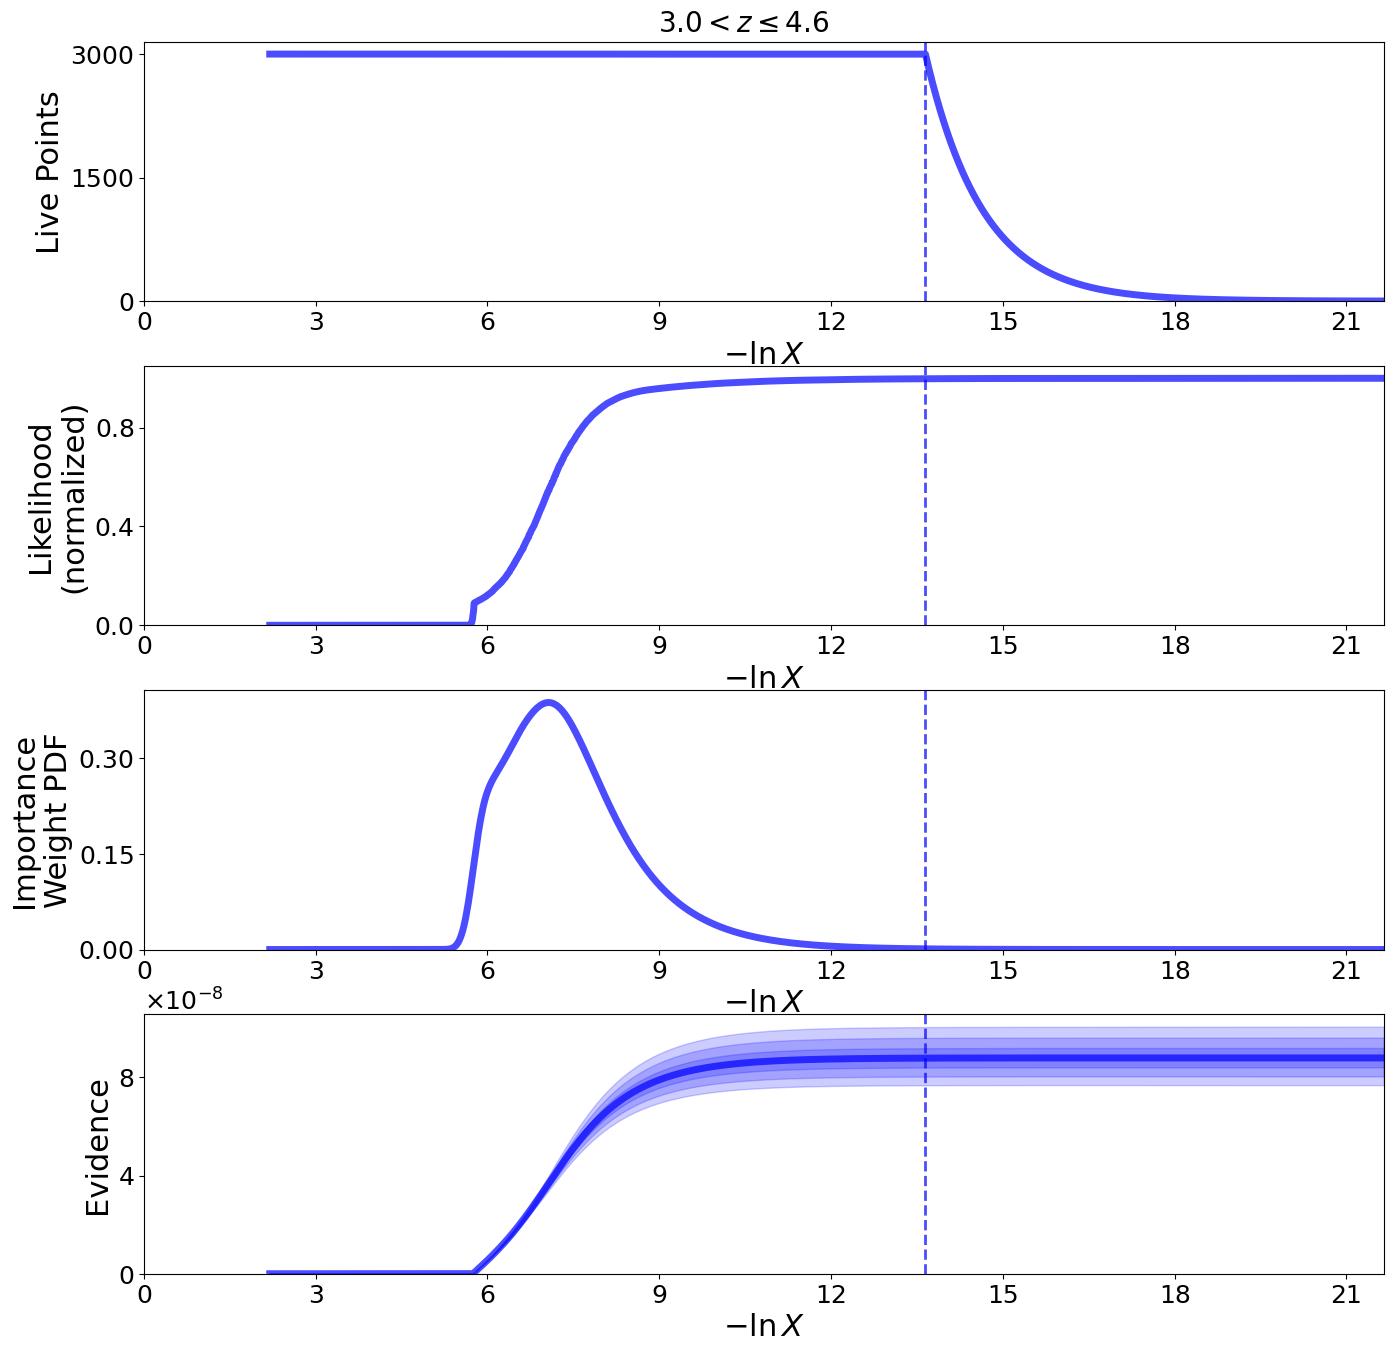

In [53]:
fig, axes = dyplot.runplot(results)  # summary (run) plot
fig.subplots_adjust(hspace=0.25)
fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_103182/3722439029.py:6: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)


Text(0.5, 1, '$3.0<z \\leq4.6$')

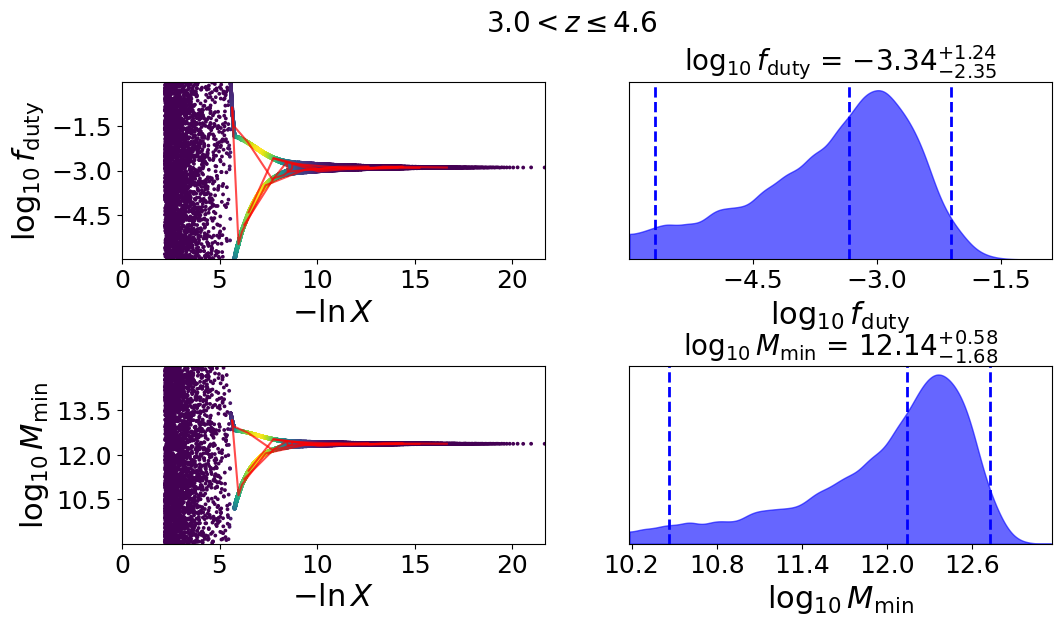

In [54]:
fig, axes = dyplot.traceplot(results, 
                             show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(5), labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'])
fig.subplots_adjust(hspace=0.6)
fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_103182/2504107271.py:7: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.95, x = 0.6)


Text(0.6, 0.95, '$3.0<z \\leq4.6$')

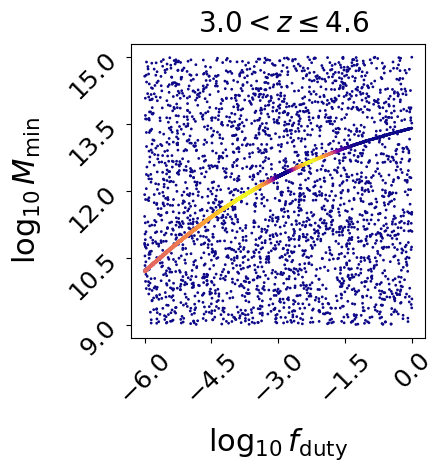

In [55]:
# initialize figure
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# plot initial run (res1; left)
fg, ax = dyplot.cornerpoints(results, cmap='plasma',
                             kde=False, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes))
fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.95, x = 0.6)

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_103182/1206956469.py:8: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1, x = 0.375)


Text(0.375, 1, '$3.0<z \\leq4.6$')

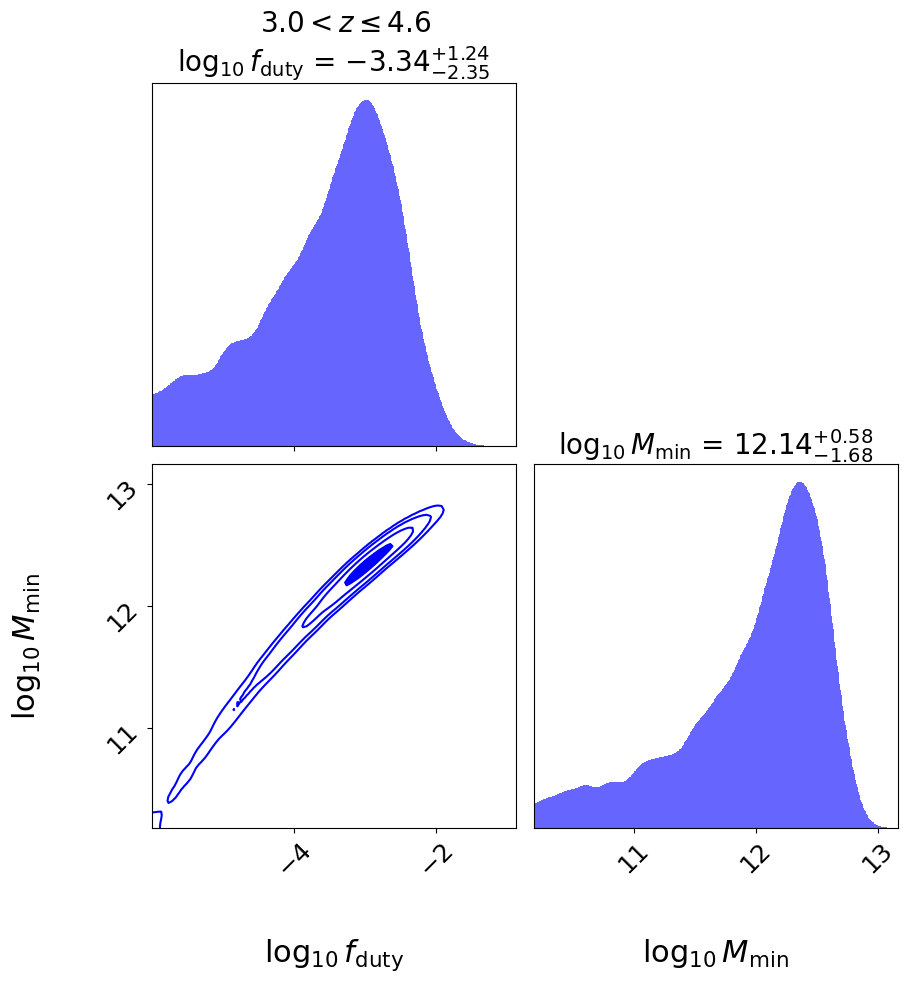

In [56]:
# # initialize figure
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# plot initial run (res1; left)
fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim),
                           truth_color='black', show_titles=True,
                           max_n_ticks=3, quantiles=None, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes[:, :3]))
fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1, x = 0.375)

In [57]:
samples, weights = results.samples, results.importance_weights()
mean, cov = dyfunc.mean_and_cov(samples, weights)
print(mean, cov)

[-3.53540659 11.97300609] [[0.90657503 0.56257785]
 [0.56257785 0.35405986]]


In [58]:
# Compute weighted quantiles
samples, weights = results.samples, results.importance_weights()

# Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
quantiles = [dyfunc.quantile(samples[:, i], [0.025, 0.5, 0.975], weights=weights) 
             for i in range(samples.shape[1])]
labels = ['log10(f_duty)', 'log10(M_min)']

for i, (lo, mid, hi) in enumerate(quantiles):
    print(f"{labels[i]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")

log10(f_duty): -3.34 + 1.24/-2.35
log10(M_min): 12.14 + 0.58/-1.68


## Convergence criterion

<>:51: SyntaxWarning: invalid escape sequence '\s'
<>:53: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\s'
<>:53: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_53835/3077279319.py:51: SyntaxWarning: invalid escape sequence '\s'
  plt.fill_between(range(len(seeds)), mean-std, mean+std, alpha = 0.5, label = '$1\sigma$')
/tmp/ipykernel_53835/3077279319.py:53: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log(z)$')


0.0<z<=1.0


30602it [01:54, 267.18it/s, +3000 | bound: 20 | nc: 1 | ncall: 81166 | eff(%): 42.988 | loglstar:   -inf < 35.689 <    inf | logz: 28.218 +/-    nan | dlogz:  0.000 >  0.001]


seed=863: logZ = 28.218 ± 0.048


30789it [01:54, 268.50it/s, +3000 | bound: 20 | nc: 1 | ncall: 83440 | eff(%): 42.005 | loglstar:   -inf < 35.689 <    inf | logz: 28.115 +/-    nan | dlogz:  0.000 >  0.001]


...

seed=395: logZ = 28.062 ± 0.049


30658it [01:52, 272.38it/s, +3000 | bound: 20 | nc: 1 | ncall: 78391 | eff(%): 44.645 | loglstar:   -inf < 35.689 <    inf | logz: 28.272 +/-    nan | dlogz:  0.000 >  0.001]


seed=539: logZ = 28.272 ± 0.048


30732it [01:51, 275.77it/s, +3000 | bound: 20 | nc: 1 | ncall: 81497 | eff(%): 42.972 | loglstar:   -inf < 35.689 <    inf | logz: 28.084 +/-    nan | dlogz:  0.000 >  0.001]


seed=55: logZ = 28.084 ± 0.048

Mean logZ: 28.150
Std logZ:  0.081


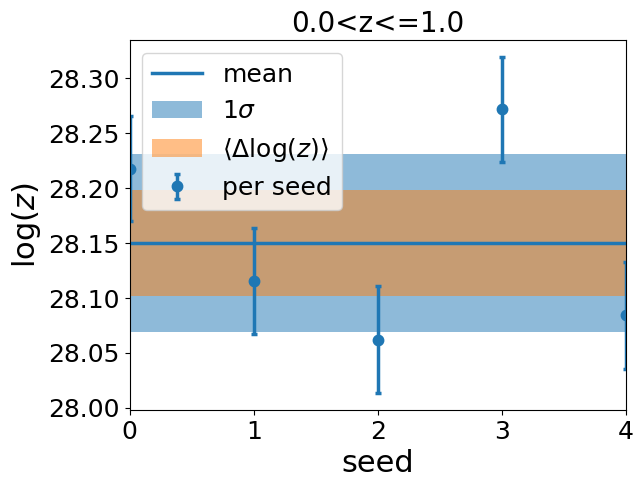

1.0<z<=2.0


32473it [02:02, 264.61it/s, +3000 | bound: 22 | nc: 1 | ncall: 85738 | eff(%): 42.874 | loglstar:   -inf < 45.209 <    inf | logz: 37.142 +/-    nan | dlogz:  0.000 >  0.001]


seed=863: logZ = 37.142 ± 0.050


32797it [01:55, 284.91it/s, +3000 | bound: 21 | nc: 1 | ncall: 83196 | eff(%): 44.637 | loglstar:   -inf < 45.209 <    inf | logz: 36.998 +/-    nan | dlogz:  0.000 >  0.001]


seed=632: logZ = 36.998 ± 0.051


...

seed=395: logZ = 37.223 ± 0.050


32573it [01:52, 290.39it/s, +3000 | bound: 21 | nc: 1 | ncall: 84625 | eff(%): 43.581 | loglstar:   -inf < 45.209 <    inf | logz: 36.919 +/-    nan | dlogz:  0.000 >  0.001]


seed=539: logZ = 36.919 ± 0.051


32543it [01:50, 293.33it/s, +3000 | bound: 20 | nc: 1 | ncall: 83515 | eff(%): 44.145 | loglstar:   -inf < 45.209 <    inf | logz: 37.008 +/-    nan | dlogz:  0.000 >  0.001]


seed=55: logZ = 37.008 ± 0.051

Mean logZ: 37.058
Std logZ:  0.109


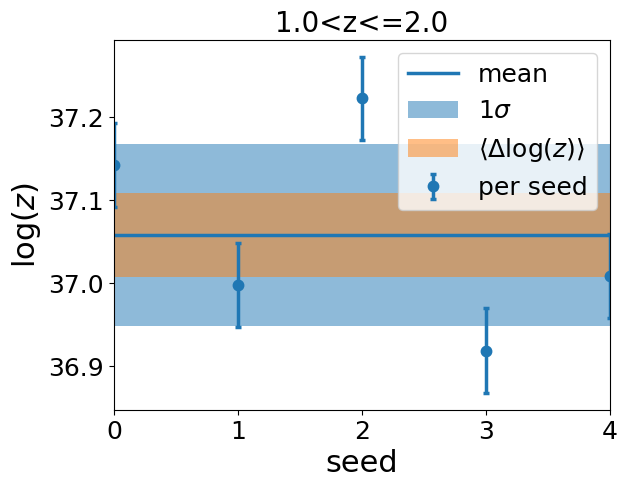

2.0<z<=3.0


31769it [01:49, 289.09it/s, +3000 | bound: 20 | nc: 1 | ncall: 87723 | eff(%): 41.038 | loglstar:   -inf < 36.644 <    inf | logz: 28.577 +/-    nan | dlogz:  0.000 >  0.001]


seed=863: logZ = 28.577 ± 0.050


31778it [01:53, 281.16it/s, +3000 | bound: 21 | nc: 1 | ncall: 85136 | eff(%): 42.342 | loglstar:   -inf < 36.644 <    inf | logz: 28.628 +/-    nan | dlogz:  0.000 >  0.001]


seed=632: logZ = 28.628 ± 0.050


...

seed=395: logZ = 28.823 ± 0.049


31687it [01:50, 287.21it/s, +3000 | bound: 20 | nc: 1 | ncall: 86492 | eff(%): 41.545 | loglstar:   -inf < 36.644 <    inf | logz: 28.552 +/-    nan | dlogz:  0.000 >  0.001]


seed=539: logZ = 28.552 ± 0.050


31800it [01:49, 289.11it/s, +3000 | bound: 20 | nc: 1 | ncall: 87803 | eff(%): 41.036 | loglstar:   -inf < 36.644 <    inf | logz: 28.440 +/-    nan | dlogz:  0.000 >  0.001]


seed=55: logZ = 28.440 ± 0.051

Mean logZ: 28.604
Std logZ:  0.126


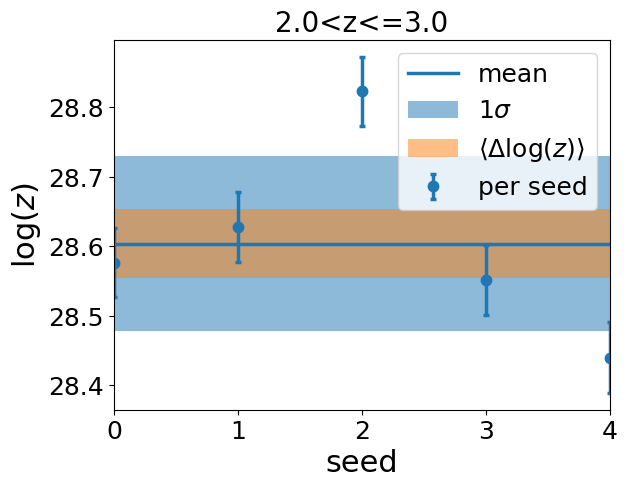

3.0<z<=4.6


27144it [01:36, 282.24it/s, +3000 | bound: 18 | nc: 1 | ncall: 82774 | eff(%): 37.787 | loglstar:   -inf < 14.319 <    inf | logz:  7.559 +/-    nan | dlogz:  0.000 >  0.001]


seed=863: logZ = 7.559 ± 0.045


27166it [01:37, 278.54it/s, +3000 | bound: 18 | nc: 1 | ncall: 84008 | eff(%): 37.238 | loglstar:   -inf < 14.319 <    inf | logz:  7.643 +/-    nan | dlogz:  0.000 >  0.001]


seed=632: logZ = 7.643 ± 0.045


...

seed=395: logZ = 7.729 ± 0.044


27147it [01:36, 282.50it/s, +3000 | bound: 18 | nc: 1 | ncall: 83107 | eff(%): 37.633 | loglstar:   -inf < 14.319 <    inf | logz:  7.558 +/-    nan | dlogz:  0.000 >  0.001]


seed=539: logZ = 7.558 ± 0.045


27147it [01:36, 282.15it/s, +3000 | bound: 18 | nc: 1 | ncall: 85303 | eff(%): 36.629 | loglstar:   -inf < 14.319 <    inf | logz:  7.517 +/-    nan | dlogz:  0.000 >  0.001]


seed=55: logZ = 7.517 ± 0.045

Mean logZ: 7.601
Std logZ:  0.076


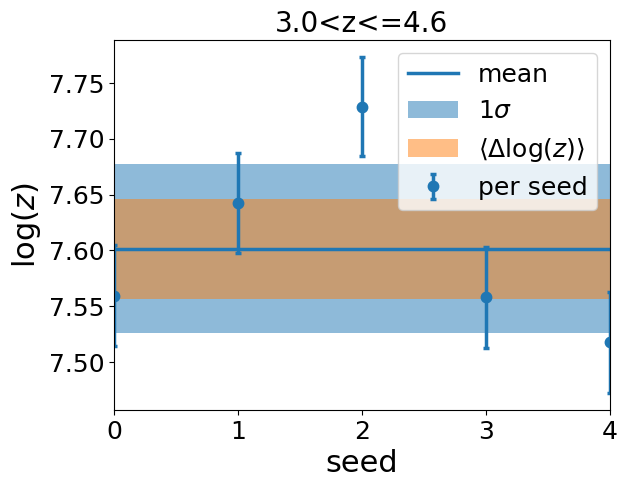

In [95]:
seeds = np.random.choice(range(1000), size=5, replace = False)

for j in z_array:

    print('{:.1f}<z<={:.1f}'.format(z_bins[j], z_bins[j+1]))

    results_list = []
    logz_values = []
    logz_err = []
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
    ix_grid = np.ix_(rpmask, rpmask)

    # check if cov is hermitian and positive definite
    if linalg.ishermitian(C) and np.all(np.linalg.eigvals(C) > 0):
        C_factor = linalg.cho_factor(C[ix_grid])
        log_det_C = 2 * np.sum(np.log(np.diag(C_factor[0])))
        solve = lambda rhs: linalg.cho_solve(C_factor, rhs)
    else:
        print('using LU decomposition')
        C_factor = linalg.lu_factor(C[ix_grid])
        log_det_C = np.sum(np.log(np.abs(np.diag(C_factor[0])))) # does abs value make sense
        solve = lambda rhs: linalg.lu_solve(C_factor, rhs)
            
    for seed in seeds:
            
        # initialize our nested sampler
        sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[j], cf_matter_chi2[j][rpmask], log_det_C, cf_chi2[j][rpmask], n_q[j], nbins], nlive = nlive, rstate=np.random.default_rng(seed))
        
        # run the sampler with checkpointing
        sampler.run_nested(dlogz = dlogz)
        results = sampler.results

        logz = results.logz[-1]
        logzerr = results.logzerr[-1]
        logz_values.append(logz)
        logz_err.append(logzerr)
        results_list.append(sampler.results)
        print(f"seed={seed}: logZ = {logz:.3f} ± {logzerr:.3f}")

    # Summary statistics
    mean = np.mean(logz_values)
    std = np.std(logz_values)
    mean_err = np.mean(logz_err)

    print(f"\nMean logZ: {mean:.3f}")
    print(f"Std logZ:  {std:.3f}")

    plt.errorbar(range(len(seeds)), logz_values, yerr = logz_err,  marker = 'o', markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none', label = 'per seed', linewidth = 2.5)
    plt.axhline(mean, linewidth = 2.5, label = 'mean')
    plt.fill_between(range(len(seeds)), mean-std, mean+std, alpha = 0.5, label = '$1\sigma$')
    plt.fill_between(range(len(seeds)), mean-mean_err, mean+mean_err, alpha = 0.5, label = r'$\langle\Delta\log(z)\rangle$')
    plt.ylabel('$\log(z)$')
    plt.xlabel('seed')
    plt.title('{:.1f}<z<={:.1f}'.format(z_bins[j], z_bins[j+1]))
    plt.legend()
    plt.xlim(0, len(seeds)-1)
    plt.show()

## Across all $z$

<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:59: SyntaxWarning: invalid escape sequence '\l'
<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:59: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_103182/1114587427.py:35: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)
/tmp/ipykernel_103182/1114587427.py:42: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)
/tmp/ipykernel_103182/1114587427.py:50: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.95, x = 0.6)
/tmp/ipykernel_103182/1114587427.py:59: SyntaxW

Summary
nlive: 3000
niter: 30704
ncall: 60736
eff(%): 46.337
logz:  4.531 +/-  0.048
0<z<=1
log10(f_duty): -2.78 + 0.18/-0.24
log10(M_min): 12.00 + 0.18/-0.24



32824it [02:19, 235.69it/s, +3000 | bound: 22 | nc: 1 | ncall: 87457 | eff(%): 42.417 | loglstar:   -inf < 21.381 <    inf | logz: 13.113 +/-    nan | dlogz:  0.000 >  0.001]


Summary
nlive: 3000
niter: 32824
ncall: 66457
eff(%): 42.417
logz: 13.113 +/-  0.051
1<z<=2
log10(f_duty): -2.82 + 0.11/-0.12
log10(M_min): 12.00 + 0.09/-0.10



31806it [02:11, 242.21it/s, +3000 | bound: 21 | nc: 1 | ncall: 86657 | eff(%): 41.606 | loglstar:   -inf < 12.816 <    inf | logz:  4.827 +/-    nan | dlogz:  0.000 >  0.001]


Summary
nlive: 3000
niter: 31806
ncall: 65657
eff(%): 41.606
logz:  4.827 +/-  0.050
2<z<=3
log10(f_duty): -2.87 + 0.16/-0.18
log10(M_min): 12.06 + 0.11/-0.13



27102it [01:52, 240.30it/s, +3000 | bound: 18 | nc: 1 | ncall: 82767 | eff(%): 37.737 | loglstar:   -inf < -9.508 <    inf | logz: -16.254 +/-    nan | dlogz:  0.000 >  0.001]


Summary
nlive: 3000
niter: 27102
ncall: 55767
eff(%): 37.737
logz: -16.254 +/-  0.045
3<z<=4
log10(f_duty): -3.36 + 0.73/-1.22
log10(M_min): 12.14 + 0.37/-0.77



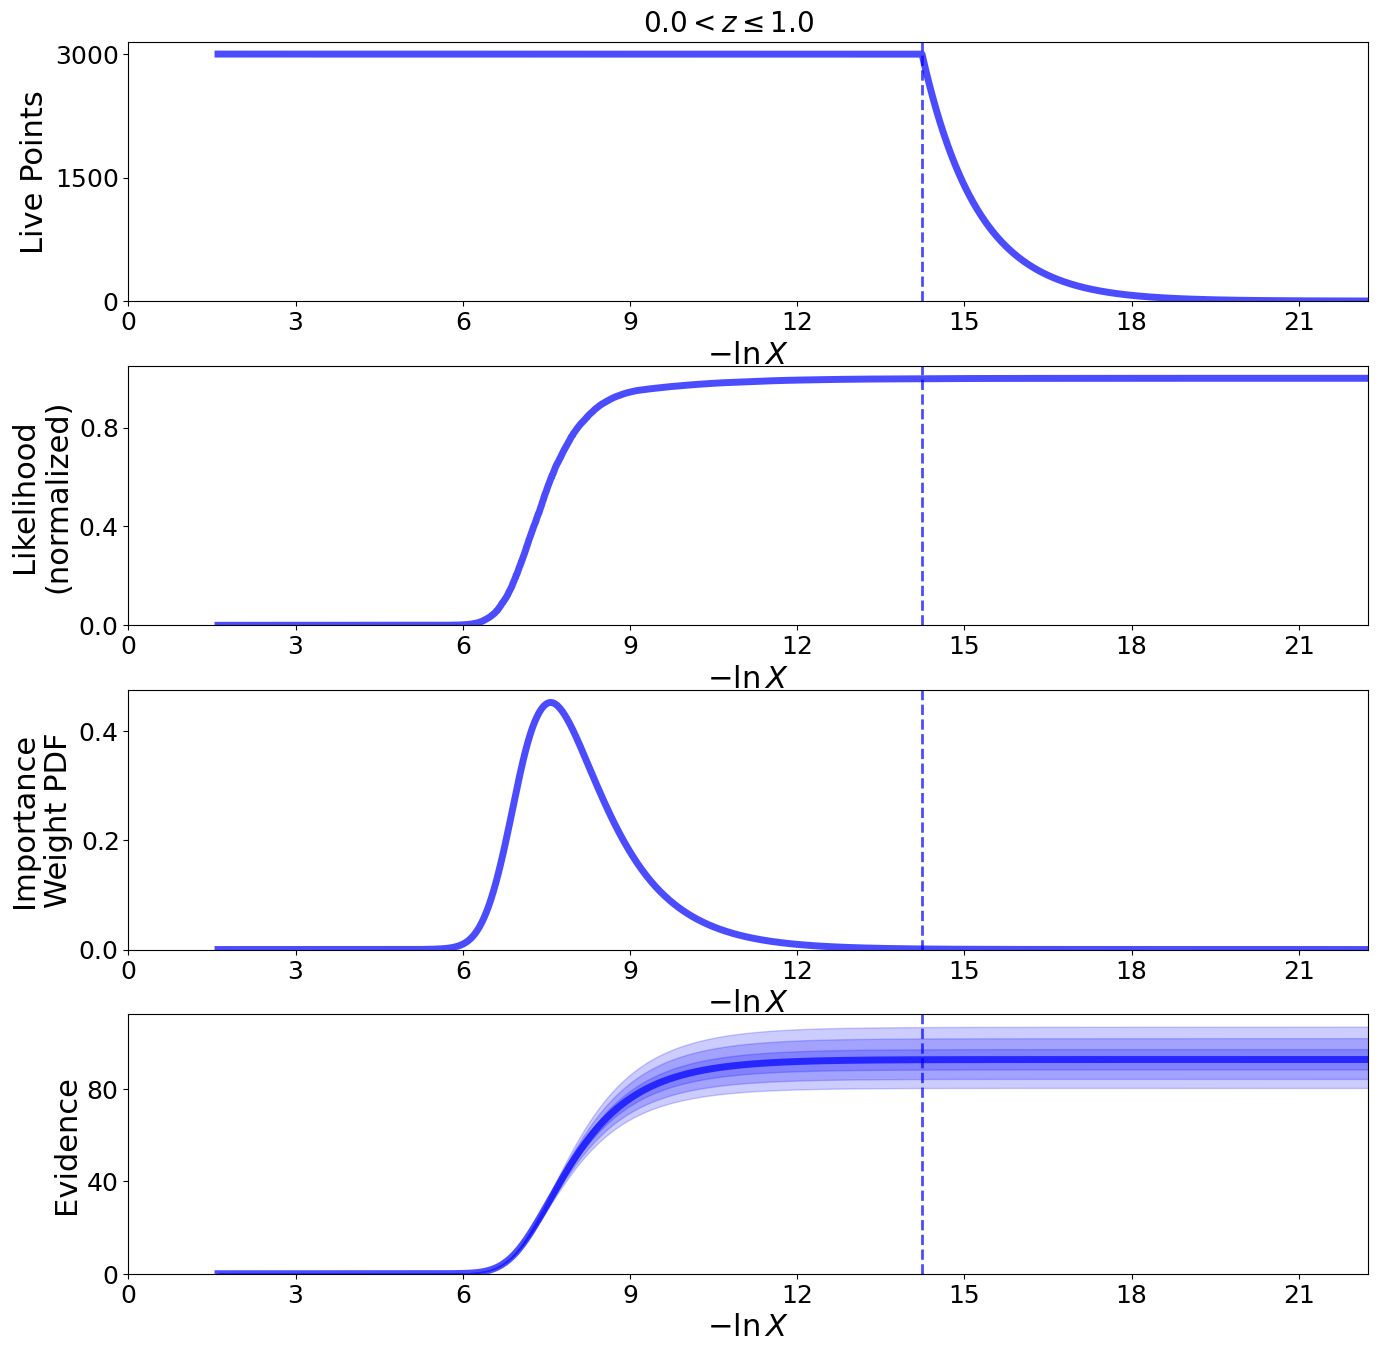

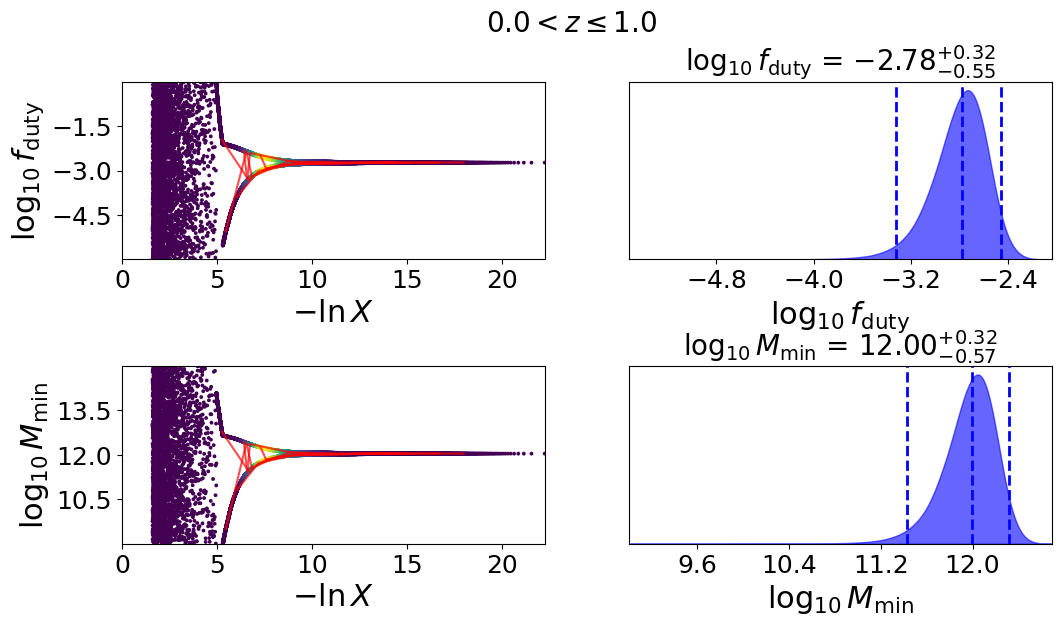

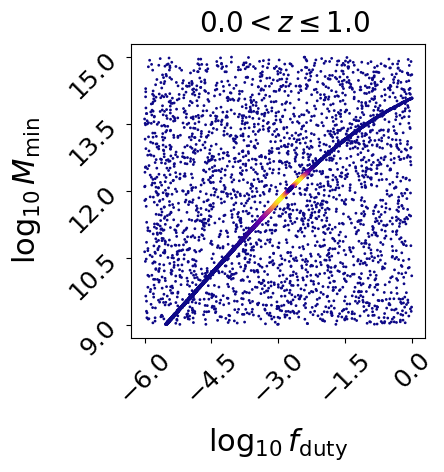

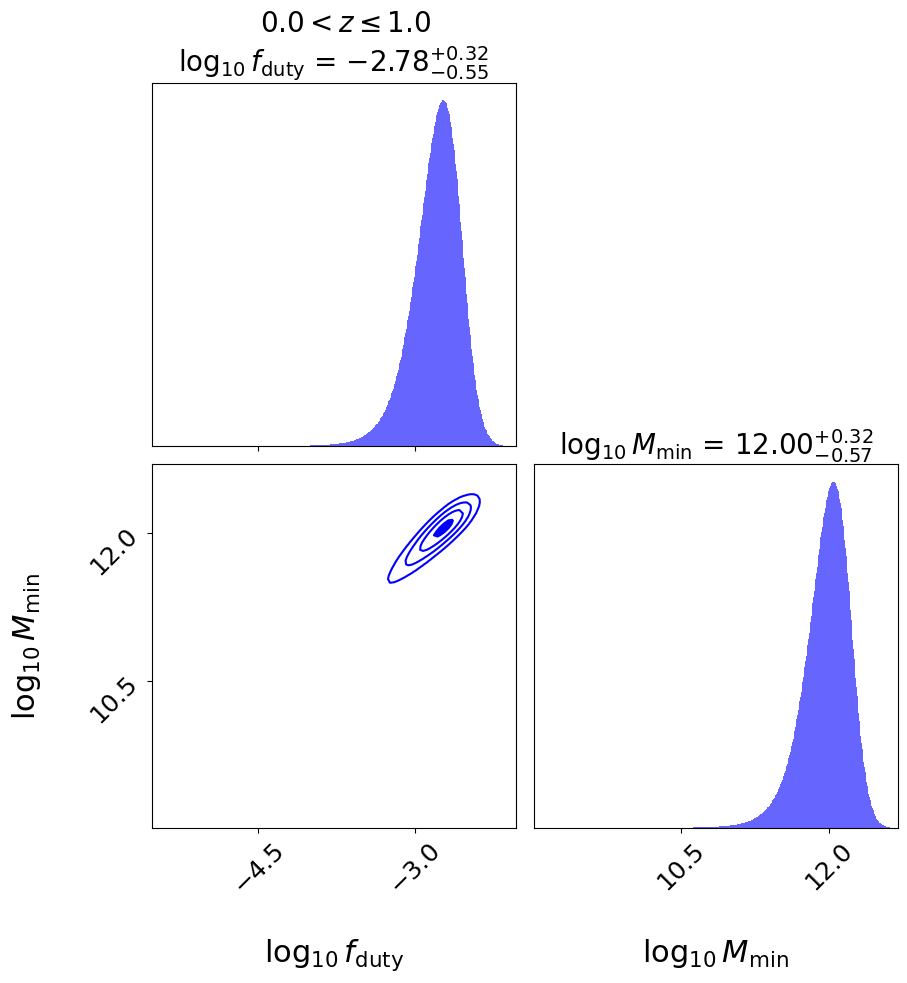

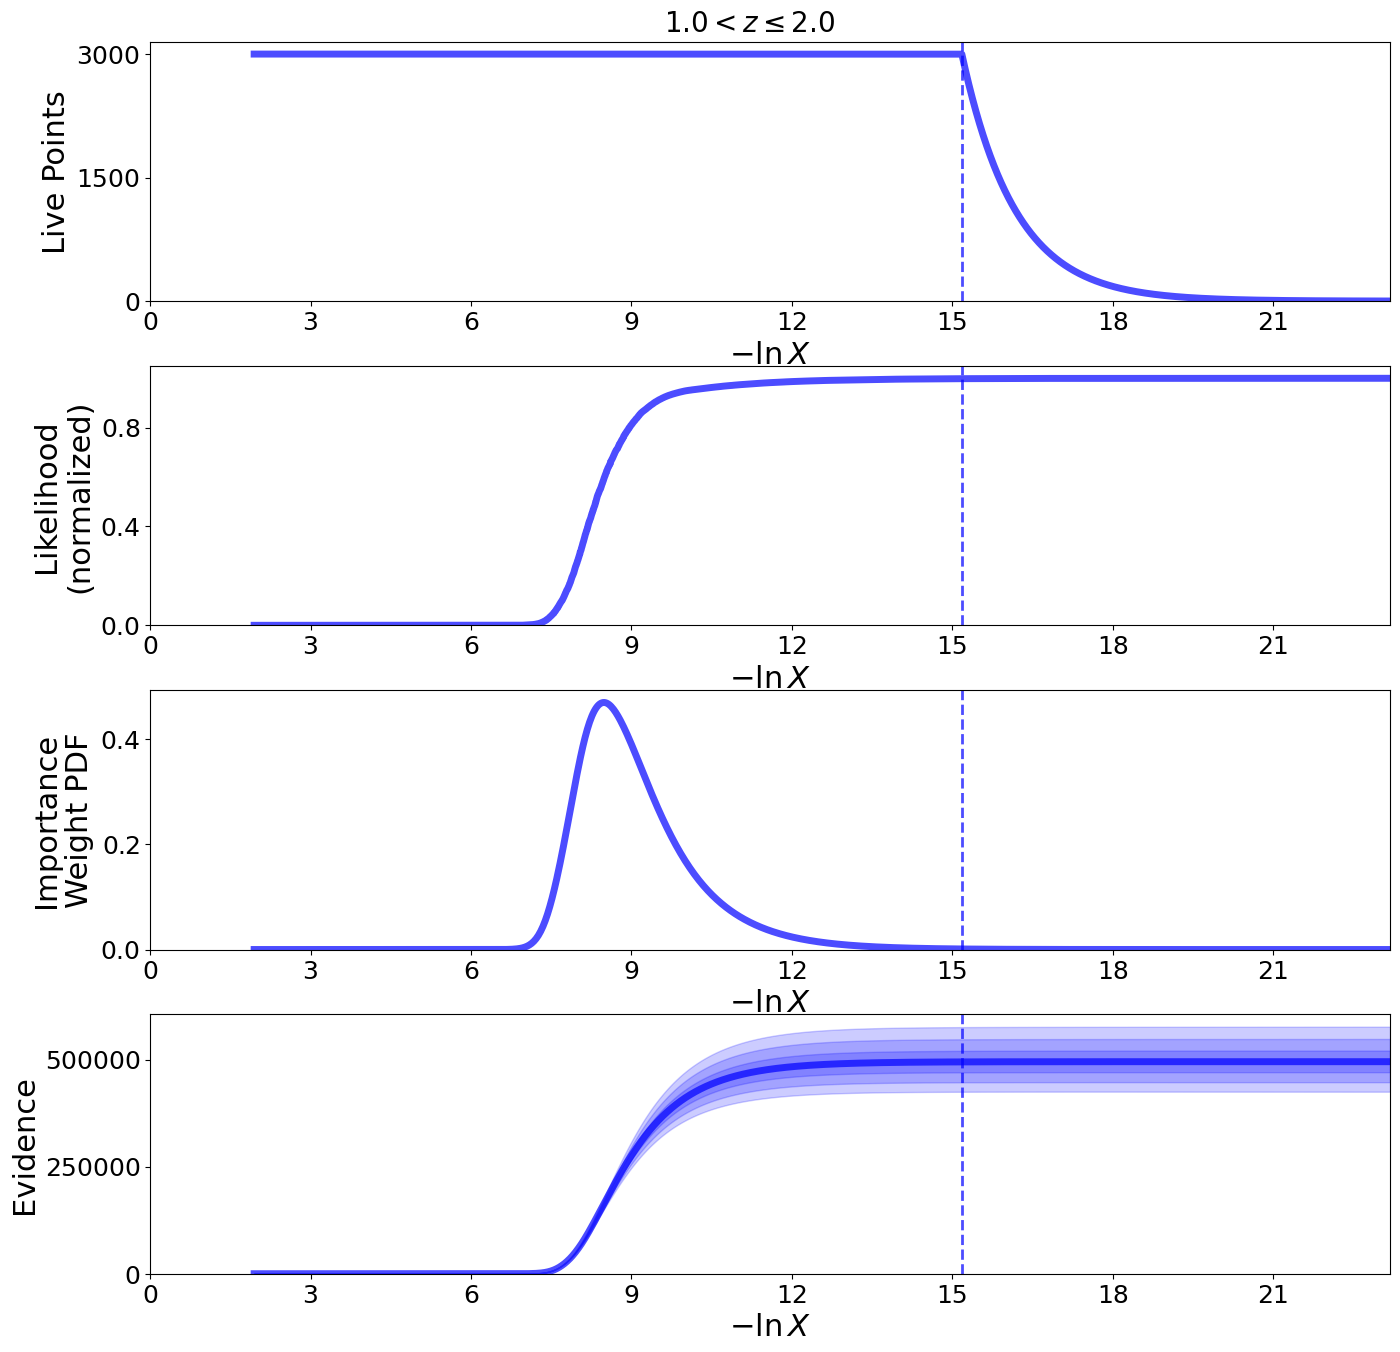

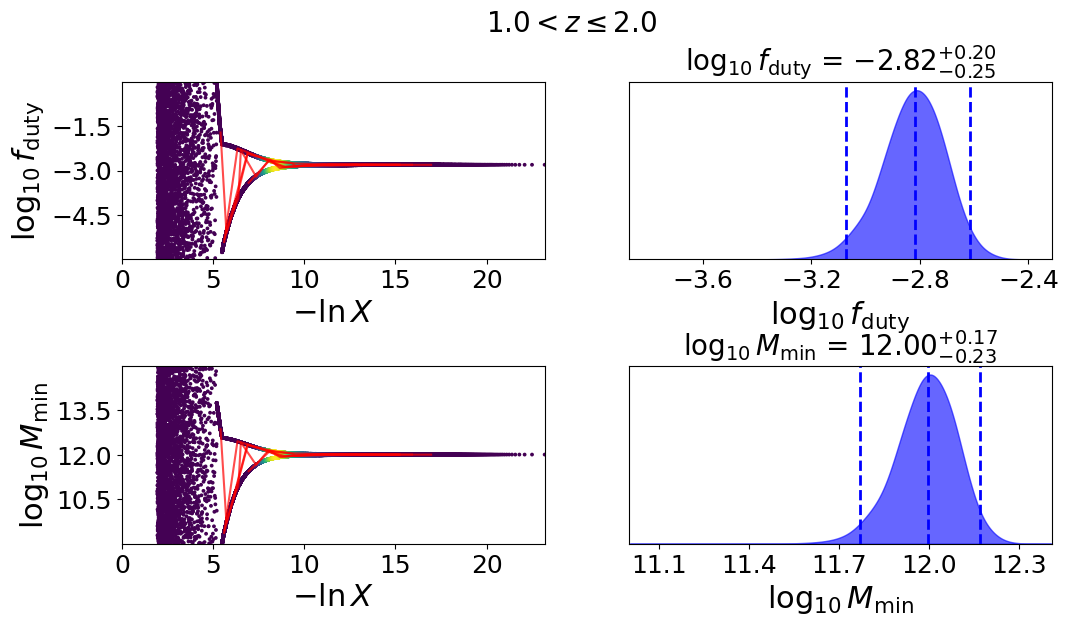

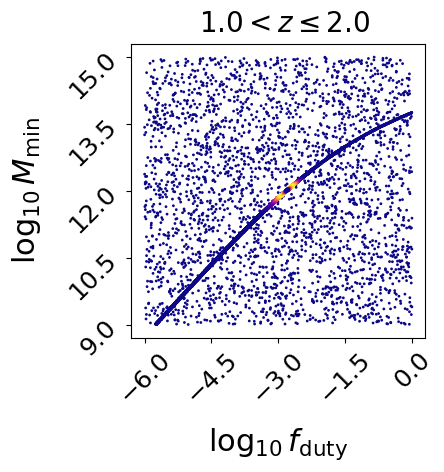

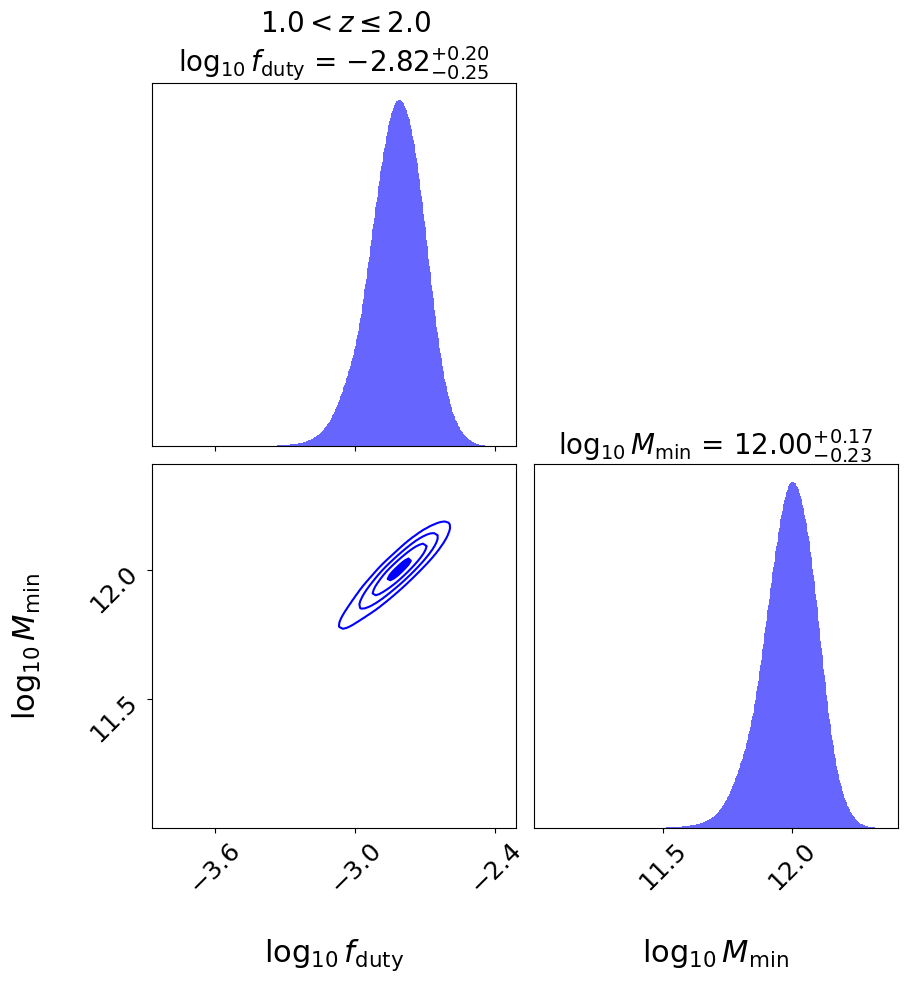

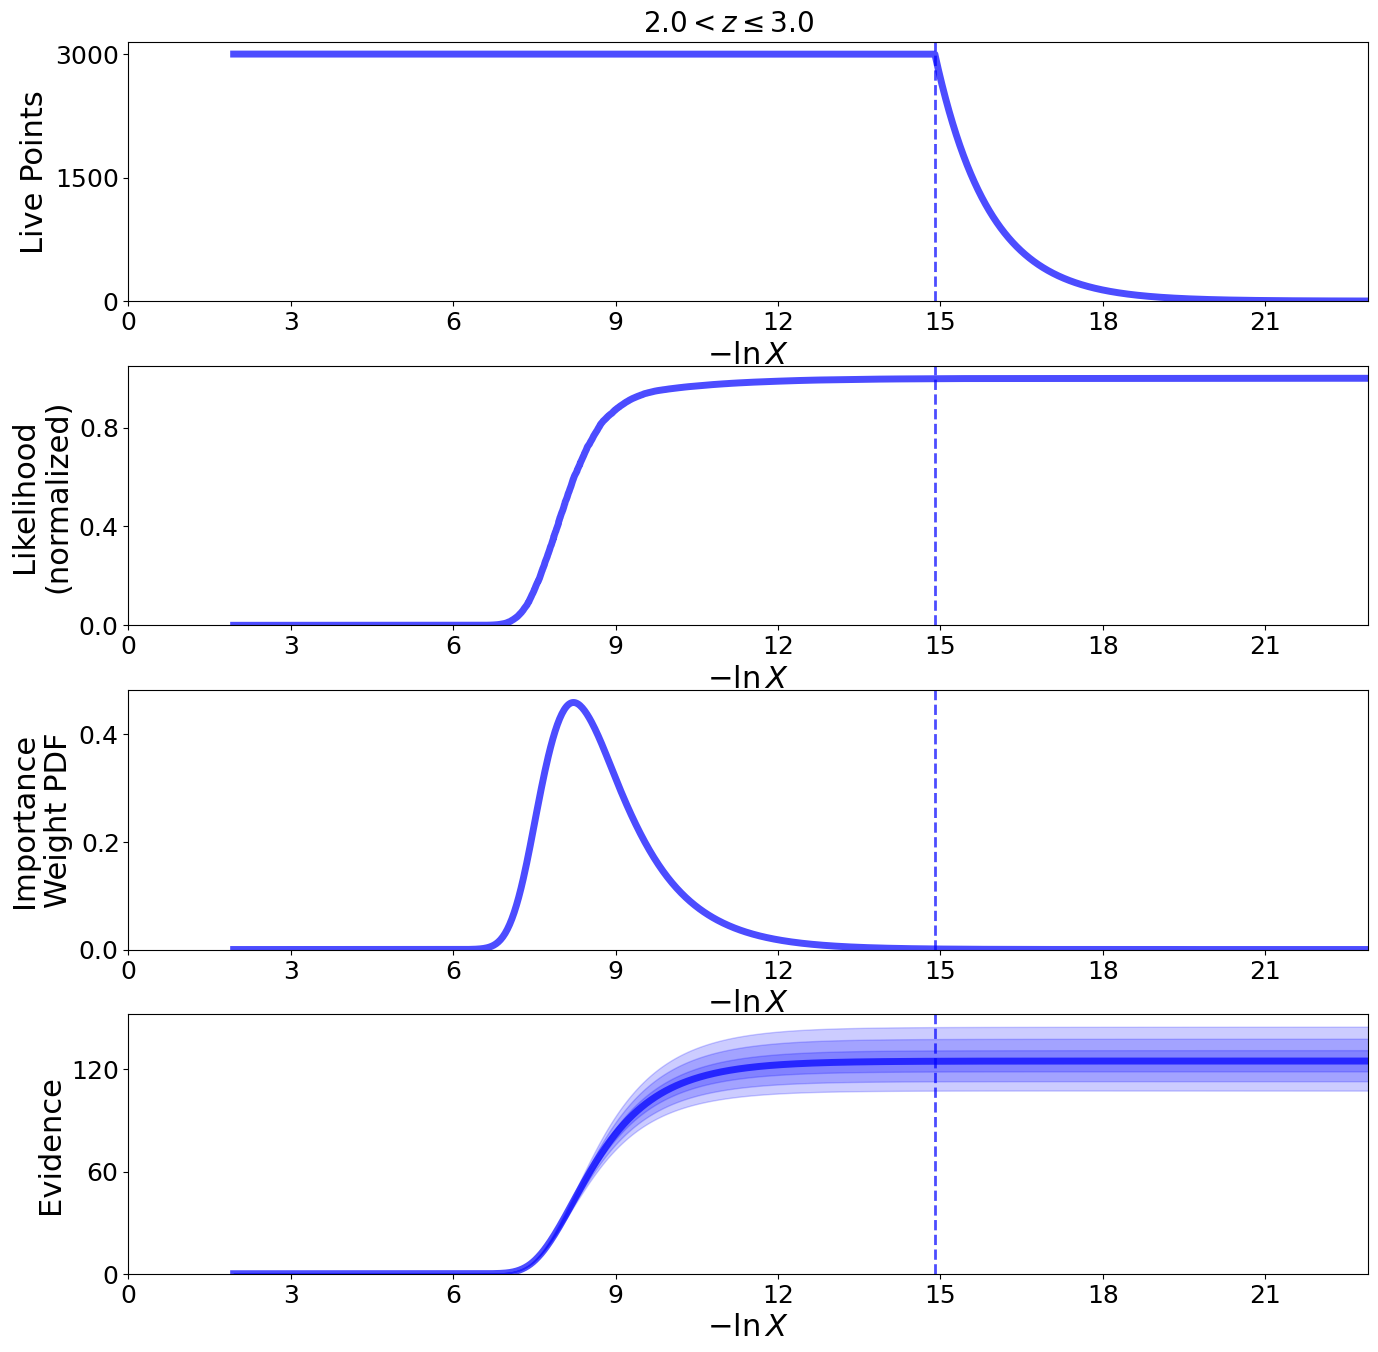

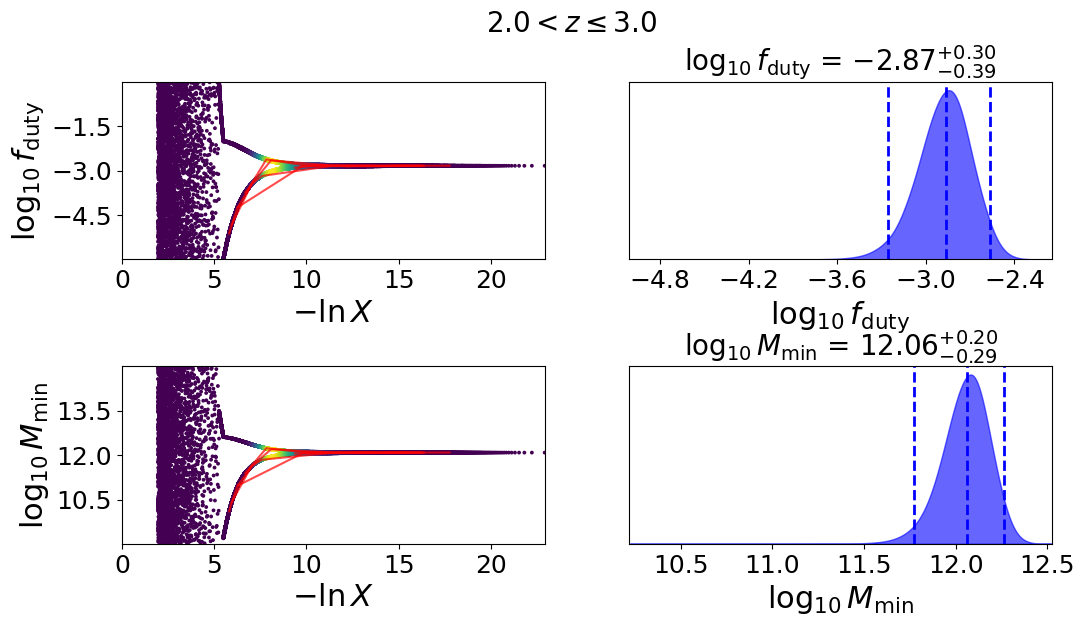

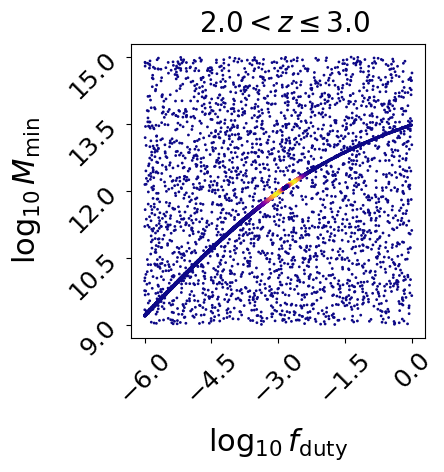

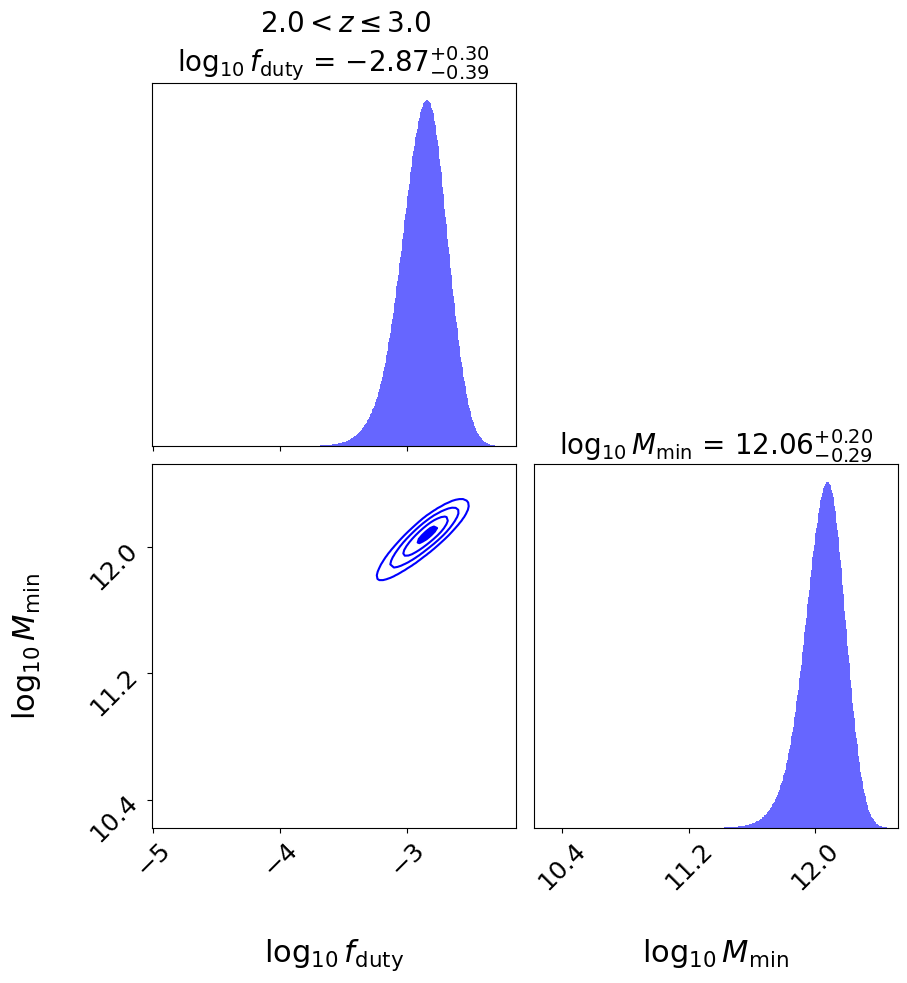

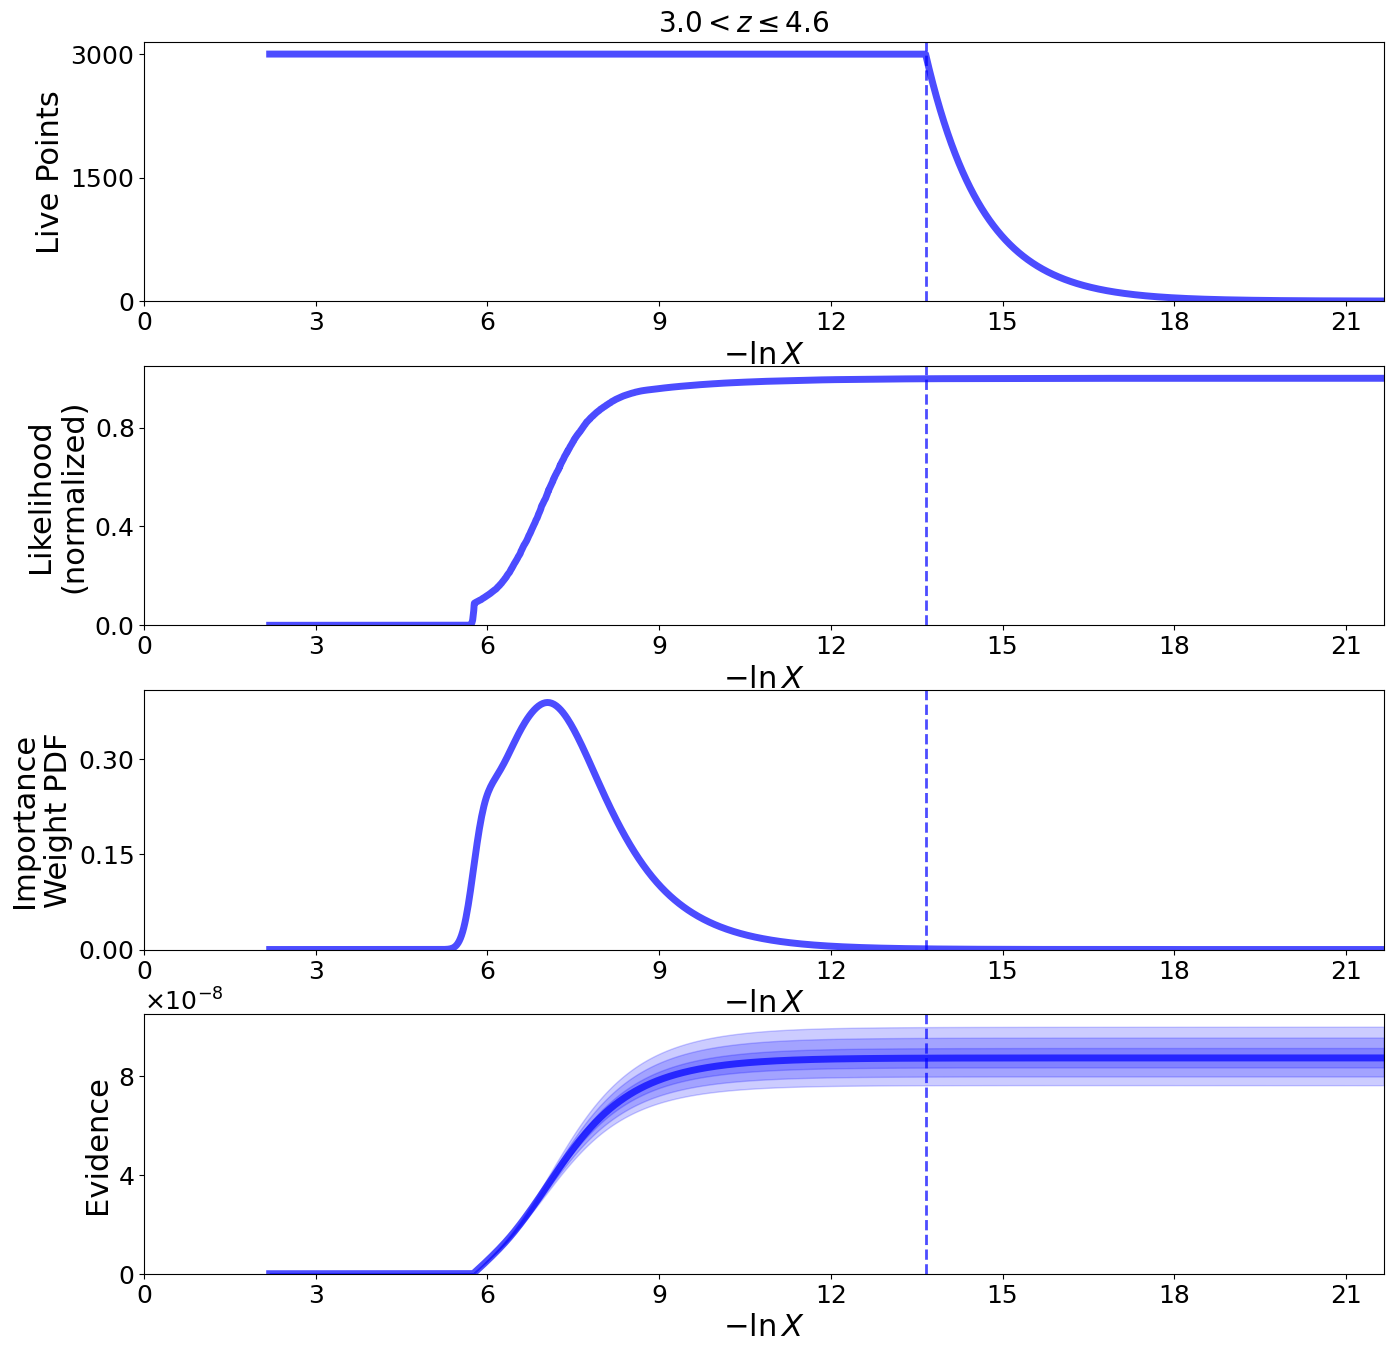

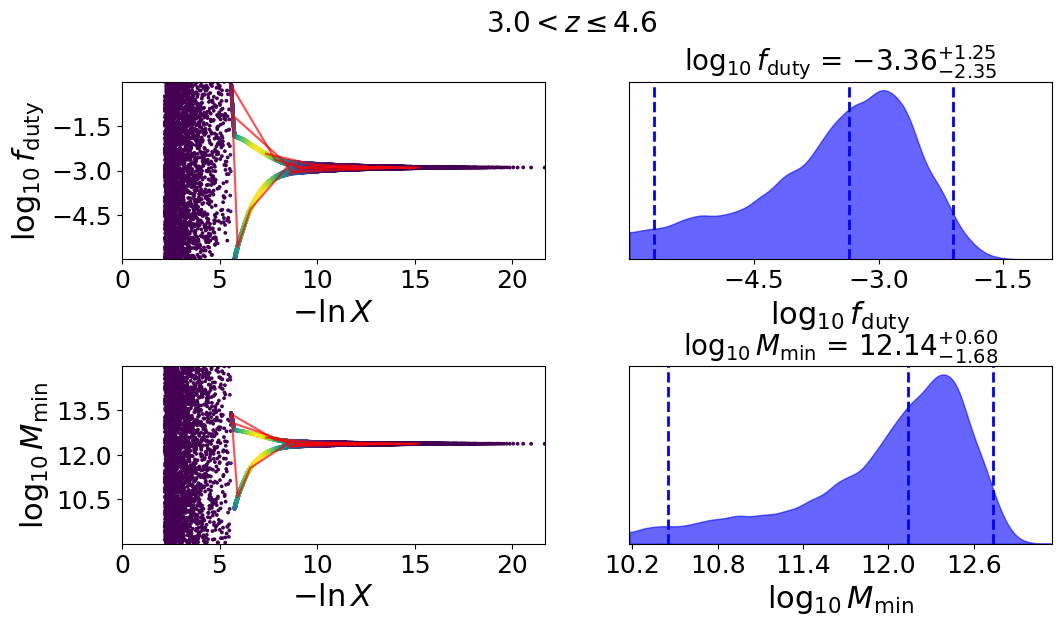

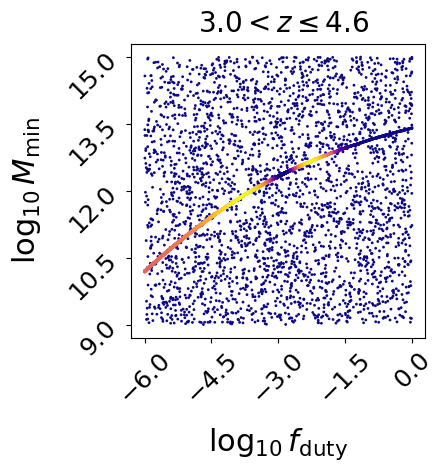

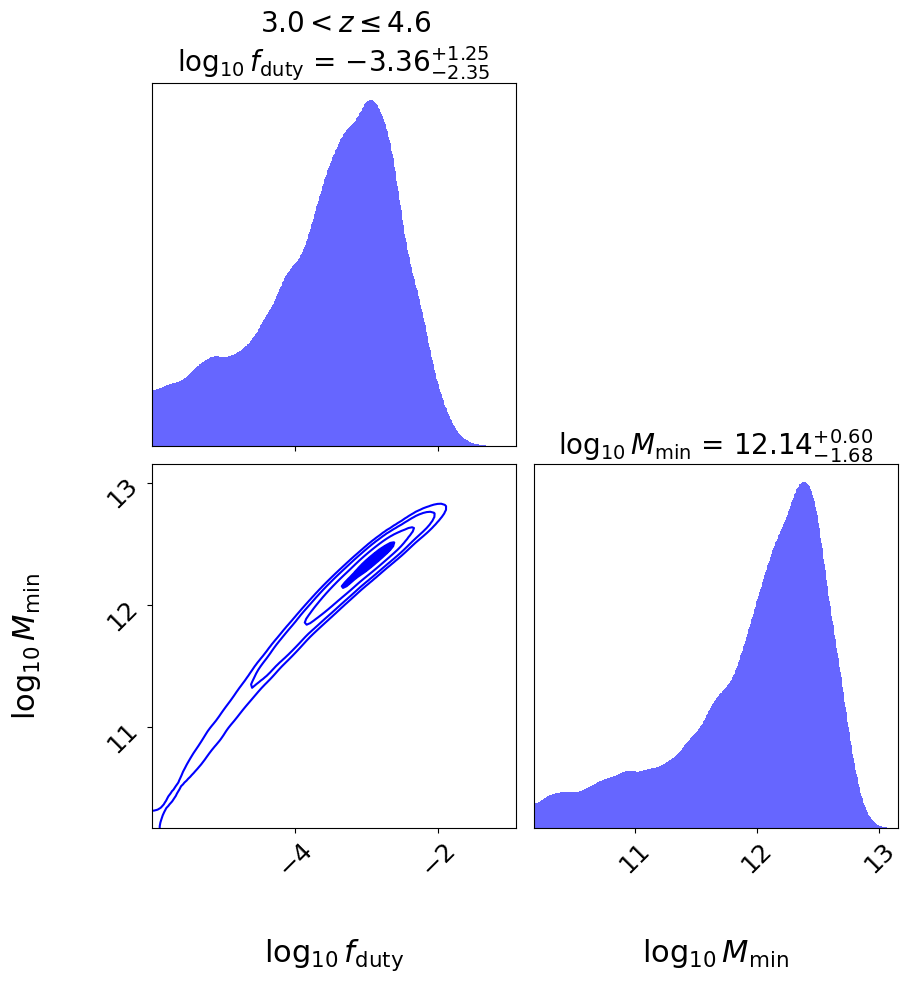

In [59]:
f_duty, M_min = [], []
labels = ['log10(f_duty)', 'log10(M_min)']
err = {i: [] for i in labels}
f_duty_samples, M_min_samples = [], []
best_fit_params = []
logz = []
for j in z_array:
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
    ix_grid = np.ix_(rpmask, rpmask)

    # check if cov is hermitian and positive definite
    if linalg.ishermitian(C) and np.all(np.linalg.eigvals(C) > 0):
        C_factor = linalg.cho_factor(C[ix_grid])
        log_det_C = 2 * np.sum(np.log(np.diag(C_factor[0])))
        solve = lambda rhs: linalg.cho_solve(C_factor, rhs)
    else:
        print('using LU decomposition')
        C_factor = linalg.lu_factor(C[ix_grid])
        log_det_C = np.sum(np.log(np.abs(np.diag(C_factor[0])))) # does abs value make sense
        solve = lambda rhs: linalg.lu_solve(C_factor, rhs)

    # initialize our nested sampler
    sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[j], cf_matter_chi2[j][rpmask], log_det_C, cf_chi2[j][rpmask], n_q[j], nbins], nlive = nlive)

    # run the sampler with checkpointing
    sampler.run_nested(dlogz = dlogz)
    results = sampler.results
    
    # Print out a summary of the results.
    results.summary()
    
    fig, axes = dyplot.runplot(results)  # summary (run) plot
    fig.subplots_adjust(hspace=0.25)
    fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)    
    
    fig, axes = dyplot.traceplot(results, 
                             show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(5), labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'])
    fig.subplots_adjust(hspace=0.6)
    fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)
    
    # initialize figure
    fig, axes = plt.subplots(1, 1, figsize=(5, 5))

    # plot initial run (res1; left)
    fg, ax = dyplot.cornerpoints(results, cmap='plasma',
                                 kde=False, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes))
    fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.95, x = 0.6)
    
    # initialize figure
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    # plot initial run (res1; left)
    fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim),
                               truth_color='black', show_titles=True,
                               max_n_ticks=3, quantiles=None, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes[:, :3]))
    fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1, x = 0.375)
    
    samples, weights = results.samples, results.importance_weights()

    # Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
    quantiles = [dyfunc.quantile(samples[:, i], [0.16, 0.5, 0.84], weights=weights) 
                 for i in range(samples.shape[1])]

    print('{}<z<={}'.format(j, j+1))
    for k, (lo, mid, hi) in enumerate(quantiles):
        print(f"{labels[k]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")
        err[labels[k]].append((lo, hi))
    print()
    
    equal_weight_samples = dyfunc.resample_equal(samples, weights)
    ind = np.random.choice(range(len(equal_weight_samples)), size = 1000, replace = False)
    f_duty_samples.append(equal_weight_samples[ind][:,0])
    M_min_samples.append(equal_weight_samples[ind][:,1])
    
    f_duty.append(quantiles[0][1])
    M_min.append(quantiles[1][1]) 

     # Get the maximum likelihood sample from dynesty results
    idx_max = np.argmax(results.logl)
    best_fit_params.append(samples[idx_max])
    logz.append(results.logz[-1])

In [60]:
np.save('../results/logz_xi_rmin{}_rmax{}_nbins{}_hard'.format(rmin, rmax, nbins), logz)
logz

[4.531044746969846, 13.112666384138548, 4.827311158418301, -16.254422309609378]

In [61]:
np.save('../results/best_fit_params_xi_rmin{}_rmax{}_nbins{}_hard'.format(rmin, rmax, nbins), best_fit_params)

### Solve for $\chi_c^2=\Delta^T x$ where $Cx=\Delta$

In [62]:
def f0_GLS_solve(x, a, cf_matter, C, cf, cosmo = cosmo_planck18, M_max = M_max, hartlap = hartlap):  #quaia):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
        
    cf_2h_zbin, _ = cf_2h(bins_m, n_m, a, cosmo, cf_matter, recenter = False)
    delta = cf-cf_2h_zbin
        
    return delta.T @ (hartlap*np.linalg.solve(C, delta))

### Add a number density constraint

In [63]:
def constraint(x, a, n_q, cosmo = cosmo_planck18, error = 0.05, M_max = M_max):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
    
    n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]

    return error-np.abs(n_q_theory-n_q)/n_q

In [64]:
for j in z_array:
    
    print('{:.1f}<z<={:.1f}'.format(z_bins[j], z_bins[j+1]))
    x = 10**f_duty[j], M_min[j]
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
    # chi2 = f0_GLS_solve(x, a_zbin[j], cf_matter_chi2[j], C, cf_chi2[j])
    chi2 = f0_GLS_solve(best_fit_params[j], a_zbin[j], cf_matter_chi2[j], C, cf_chi2[j])
    df = nbins-len(x)

    print('           chi^2: {:.2f}'.format(chi2))
    print('   reduced chi^2: {:.2f}'.format(chi2/df))
    print('         delta n: {:.2e}'.format(constraint(x, a_zbin[j], n_q[j])))
    print('condition number: {:.2f}'.format(np.linalg.cond(C)))
    print('             PTE: {:.2f}\n'.format(stats.chi2.sf(chi2, df)))

0.0<z<=1.0
           chi^2: 60.65
   reduced chi^2: 2.17
         delta n: 4.86e-02
condition number: 354.08
             PTE: 0.00

1.0<z<=2.0
           chi^2: 39.41
   reduced chi^2: 1.41
         delta n: 4.79e-02
condition number: 406.08
             PTE: 0.07

2.0<z<=3.0
           chi^2: 125.97
   reduced chi^2: 4.50
         delta n: 4.98e-02
condition number: 379.85
             PTE: 0.00

3.0<z<=4.6
           chi^2: 46.03
   reduced chi^2: 1.64
         delta n: 4.81e-02
condition number: 306.98
             PTE: 0.02



## Plot results

In [65]:
zbin = 1/np.array(a_zbin)-1

In [66]:
z_eff = [0.5, 1.5, 2.5, 3.5]

In [67]:
M_min_err_hi = [0.04, 0.02, 0.03, 0.1]
M_min_err_lo = [0.05, 0.02, 0.03, 0.12]

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_103182/490838582.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')


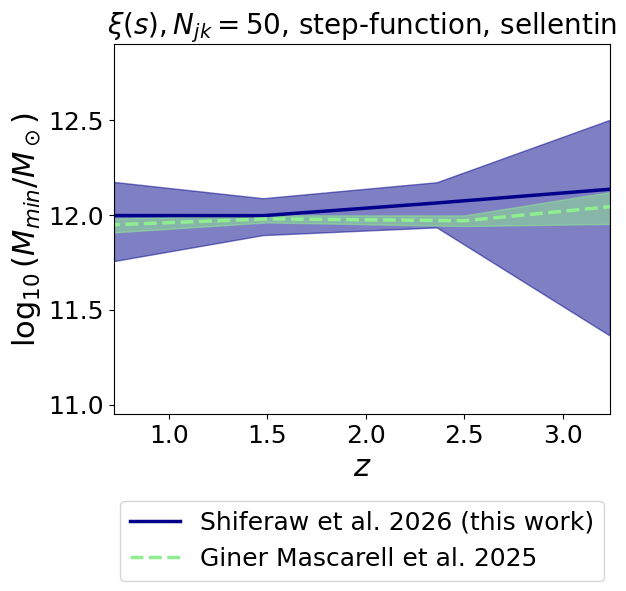

In [68]:
M_min_lo, M_min_hi = np.array(err['log10(M_min)'])[:,0], np.array(err['log10(M_min)'])[:,1]
plt.plot(zbin, M_min, color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.fill_between(zbin, M_min_lo, M_min_hi, alpha = 0.5, color = 'darkblue')
plt.plot(z_eff, M_min_array, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.fill_between(z_eff, M_min_array+np.array(M_min_array)/M_min_array_old*M_min_err_hi, M_min_array-np.array(M_min_array)/M_min_array_old*M_min_err_lo, alpha = 0.5, color = 'lightgreen')
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.ylim(10.95,12.9)
plt.title(r'$\xi(s), N_{{jk}}={}$, step-function, sellentin'.format(N))
plt.show()

In [69]:
np.save('../results/M_min_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask_sellentin_nlive{}_dlogz{}_hard.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo, nlive, dlogz), M_min)

In [70]:
np.save('../results/log10(M_min)_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask_sellentin_nlive{}_dlogz{}_hard.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo, nlive, dlogz), np.array(err['log10(M_min)']))

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_103182/965534903.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(f_{duty})$')


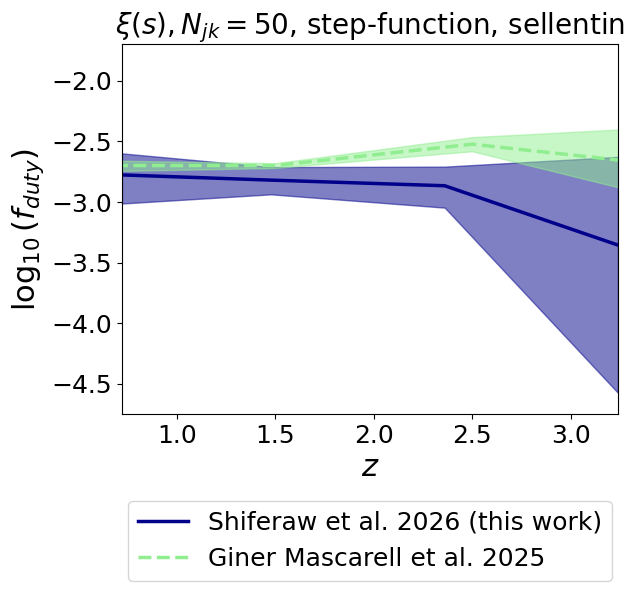

In [71]:
f_duty_lo, f_duty_hi = np.array(err['log10(f_duty)'])[:,0], np.array(err['log10(f_duty)'])[:,1]
plt.plot(zbin, f_duty, color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.fill_between(zbin, f_duty_lo, f_duty_hi, alpha = 0.5, color = 'darkblue')
plt.fill_between(z_eff, np.log10(np.array(fduty)+np.array(fduty)/fduty_old*fduty_err_hi), np.log10(np.array(fduty)-np.array(fduty)/fduty_old*fduty_err_lo), alpha = 0.5, color = 'lightgreen')
plt.plot(z_eff, np.log10(fduty), label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.ylim(-4.75,-1.7)
plt.title(r'$\xi(s), N_{{jk}}={}$, step-function, sellentin'.format(N))
plt.show()

In [72]:
np.save('../results/f_duty_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask_sellentin_nlive{}_dlogz{}_hard.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo, nlive, dlogz), f_duty)

In [73]:
np.save('../results/log10(f_duty)_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask_sellentin_nlive{}_dlogz{}_hard.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo, nlive, dlogz), np.array(err['log10(f_duty)']))

In [74]:
b_eff_cf20 = np.load('../results/b_eff_cf20_planck18.npy')

## Calculate 16th and 84th percentile of derived parameters

<>:62: SyntaxWarning: invalid escape sequence '\l'
<>:62: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_103182/2266914990.py:62: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.1f}<z \leq{:.1f}$'.format(G_hi, z_bins[j], z_bins[j+1]))


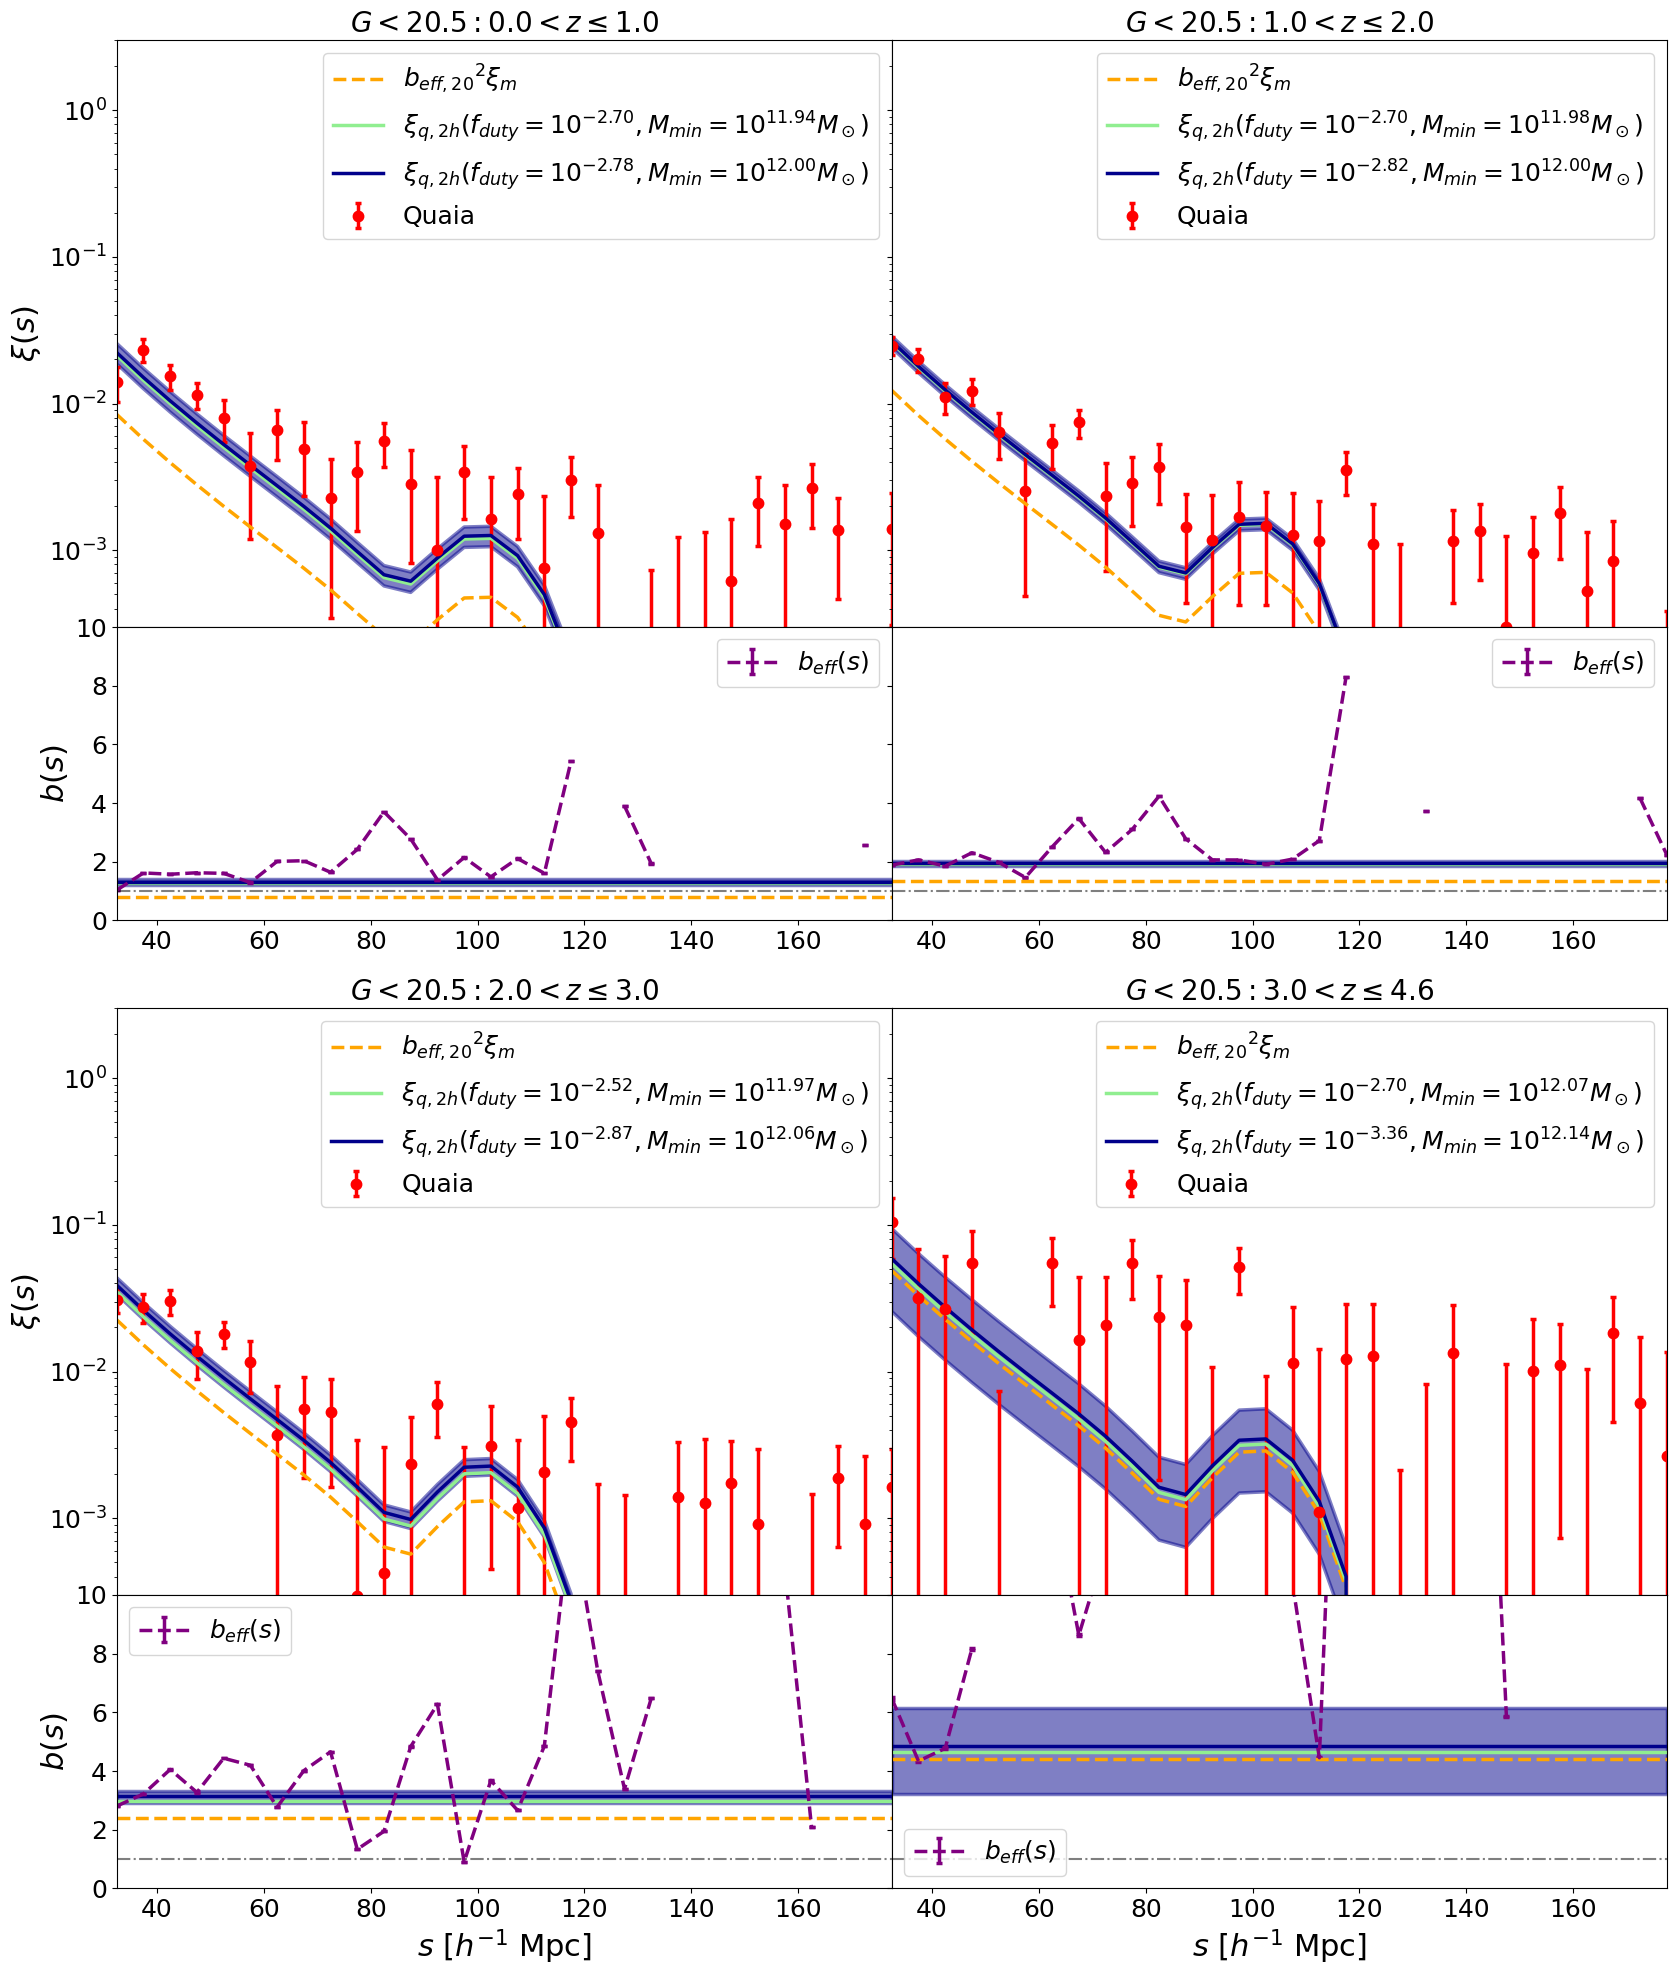

In [75]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
   
    ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.plot(quaia.recenter(rbins_chi2), b_eff_cf20[j]**2*cf_matter_chi2[j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = 'orange', linestyle = '--')
    if quaia.recenter(rbins_chi2)[0] < 30:
        ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                          alpha = 0.5, label = 'scales excluded from fit')
        ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                          alpha = 0.5)

    # old fit
    cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_chi2[j], recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5, 
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty[j]), M_min_array[j]),
             color = 'lightgreen')
    ax2.axhline(b_q, linewidth = 2.5, color = 'lightgreen')

    # plot new fit
    n_m=np.ones(np.shape(bins))*f_duty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5,
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = 'darkblue')
    
    cf_2h_samples, b_q_samples=[], []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        cf_2h_sample, b_q_sample = cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                                recenter = False)
        cf_2h_samples.append(cf_2h_sample)
        b_q_samples.append(b_q_sample)
    cf_2h_16, cf_2h_50, cf_2h_84 = np.percentile(cf_2h_samples, [16, 50, 84], axis=0)
    b_q_16, b_q_50, b_q_84 = np.percentile(b_q_samples, [16, 50, 84])

    ax1.fill_between(quaia.recenter(rbins_chi2), cf_2h_16, cf_2h_84, linewidth = 2.5, alpha = 0.5,
             color = 'darkblue')
    ax2.axhline(b_q, linewidth = 2.5, color = 'darkblue')
    ax2.fill_between(quaia.recenter(rbins_chi2), [b_q_16]*nbins, [b_q_84]*nbins, linewidth = 2.5, color = 'darkblue', alpha = 0.5)
    
    ax2.errorbar(quaia.recenter(rbins_chi2), b_cf_chi2[j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'purple', yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')
    ax2.axhline(b_eff_cf20[j], linewidth = 2.5, color = 'orange', linestyle = '--')
    if quaia.recenter(rbins_chi2)[0] < 30:
        ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                          alpha = 0.5, label = 'scales excluded from fit')
        ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                          alpha = 0.5)
    
    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.1f}<z \leq{:.1f}$'.format(G_hi, z_bins[j], z_bins[j+1]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 3)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax2.set_ylim(0, 10)
    ax2.legend()
    
    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=4

plt.show()

<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_103182/3736729021.py:41: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))


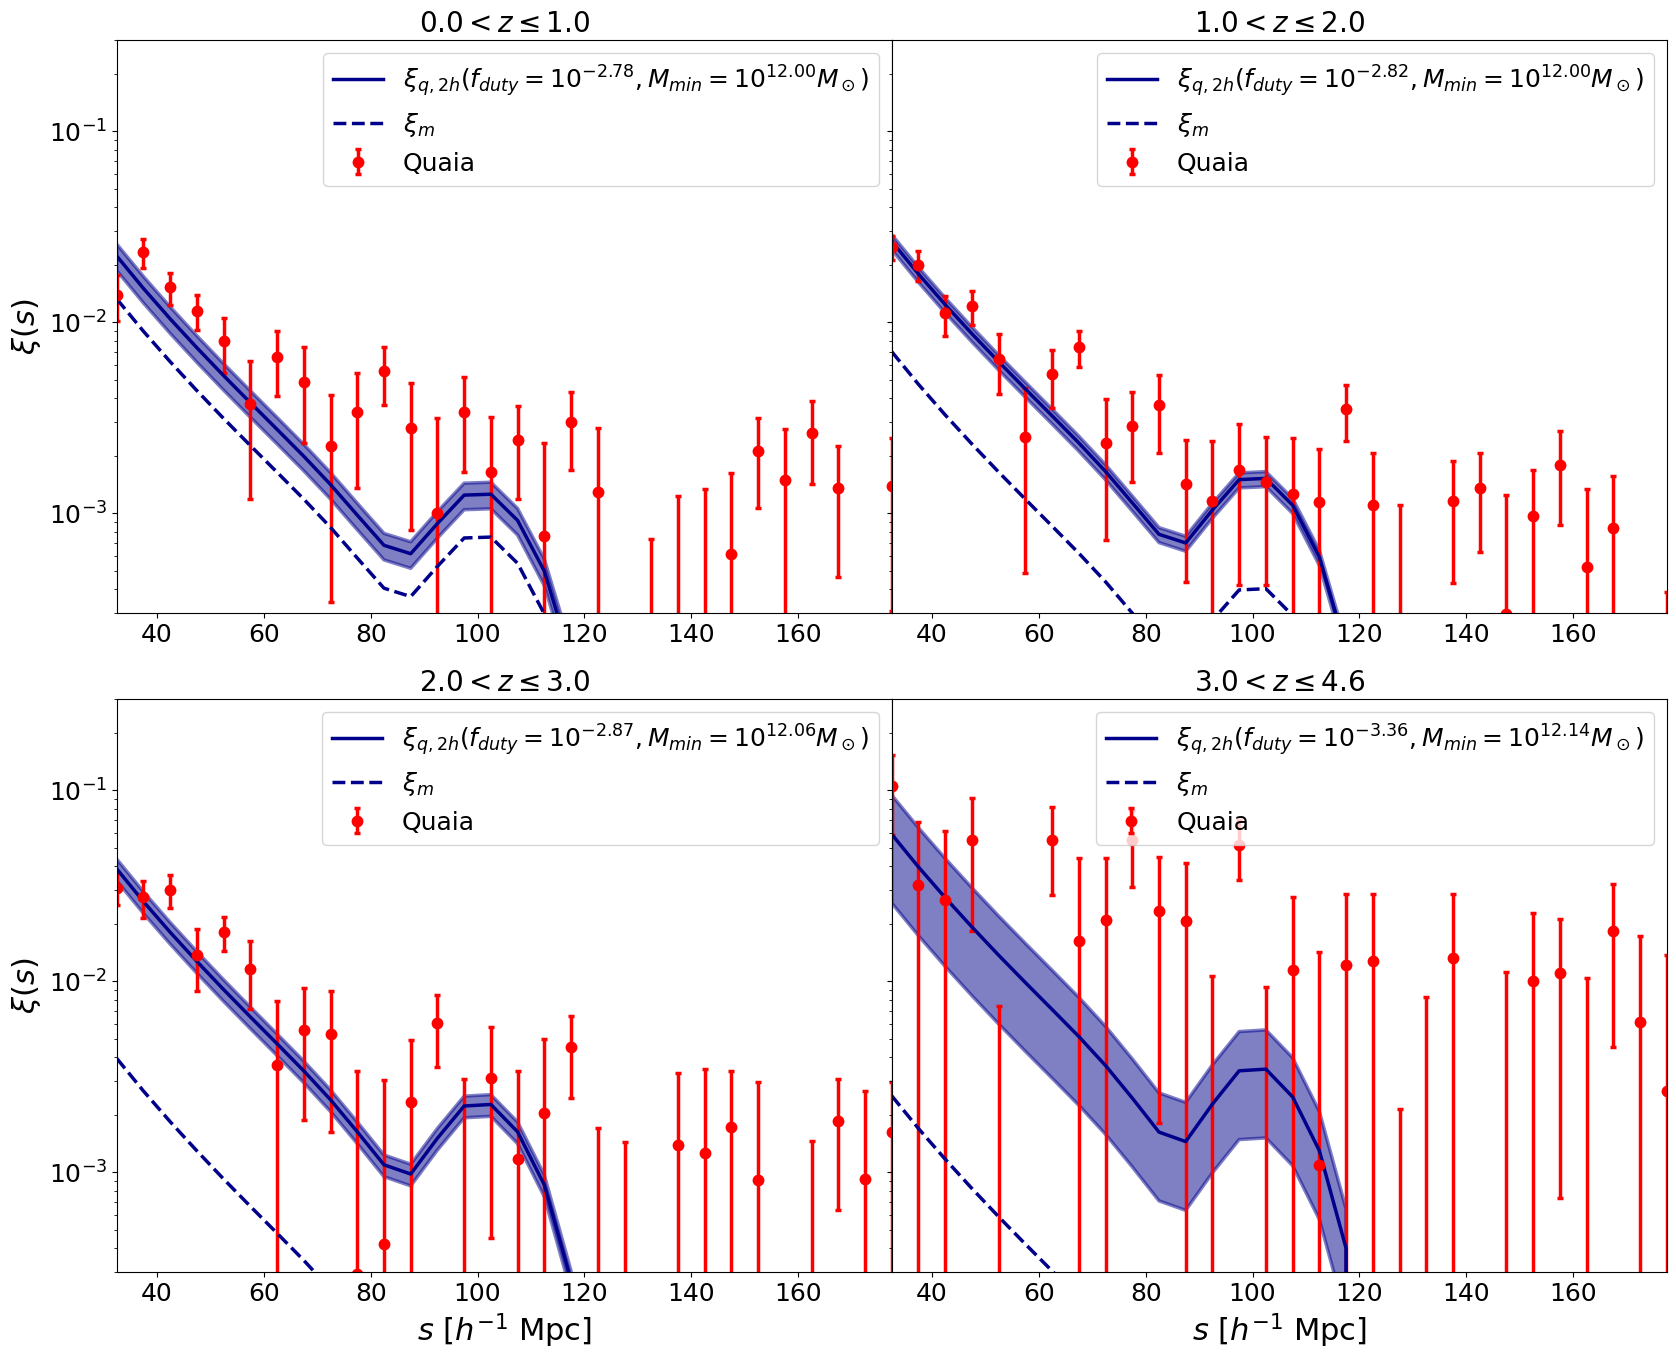

In [76]:
# remove bottom panel and just print bq somewhere
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
           
    ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    if quaia.recenter(rbins_chi2)[0] < 30:
        ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                          alpha = 0.5, label = 'scales excluded from fit')
        ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                          alpha = 0.5)

    # plot new fit
    n_m=np.ones(np.shape(bins))*f_duty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5,
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = 'darkblue')
    ax1.plot(quaia.recenter(rbins_chi2), cf_matter_chi2[j], linewidth = 2.5,
             label = r'$\xi_{{m}}$', linestyle = '--', 
             color = 'darkblue')

    cf_2h_samples = []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*f_duty_samples[j][i]
        cf_2h_sample, _ = cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                                recenter = False)
        cf_2h_samples.append(cf_2h_sample)
    cf_2h_16, cf_2h_50, cf_2h_84 = np.percentile(cf_2h_samples, [16, 50, 84], axis=0)
    ax1.fill_between(quaia.recenter(rbins_chi2), cf_2h_16, cf_2h_84, linewidth = 2.5, alpha = 0.5,
             color = 'darkblue')   

    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_ylim(3e-4, 3e-1)
    ax1.legend()
    
    if j % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')

    else:
        ax1.set_yticklabels([])

    if j > 1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=2

plt.show()

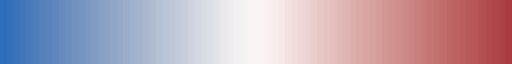

In [77]:
cmap_M_min = sns.color_palette("vlag", n_colors = len(bins))
palette_M_min = matplotlib.colors.ListedColormap(cmap_M_min)
palette_M_min

<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\D'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_103182/1322281163.py:42: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.1f}<z \leq{:.1f}$'.format(G_hi, z_bins[j], z_bins[j+1]))
/tmp/ipykernel_103182/1322281163.py:61: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


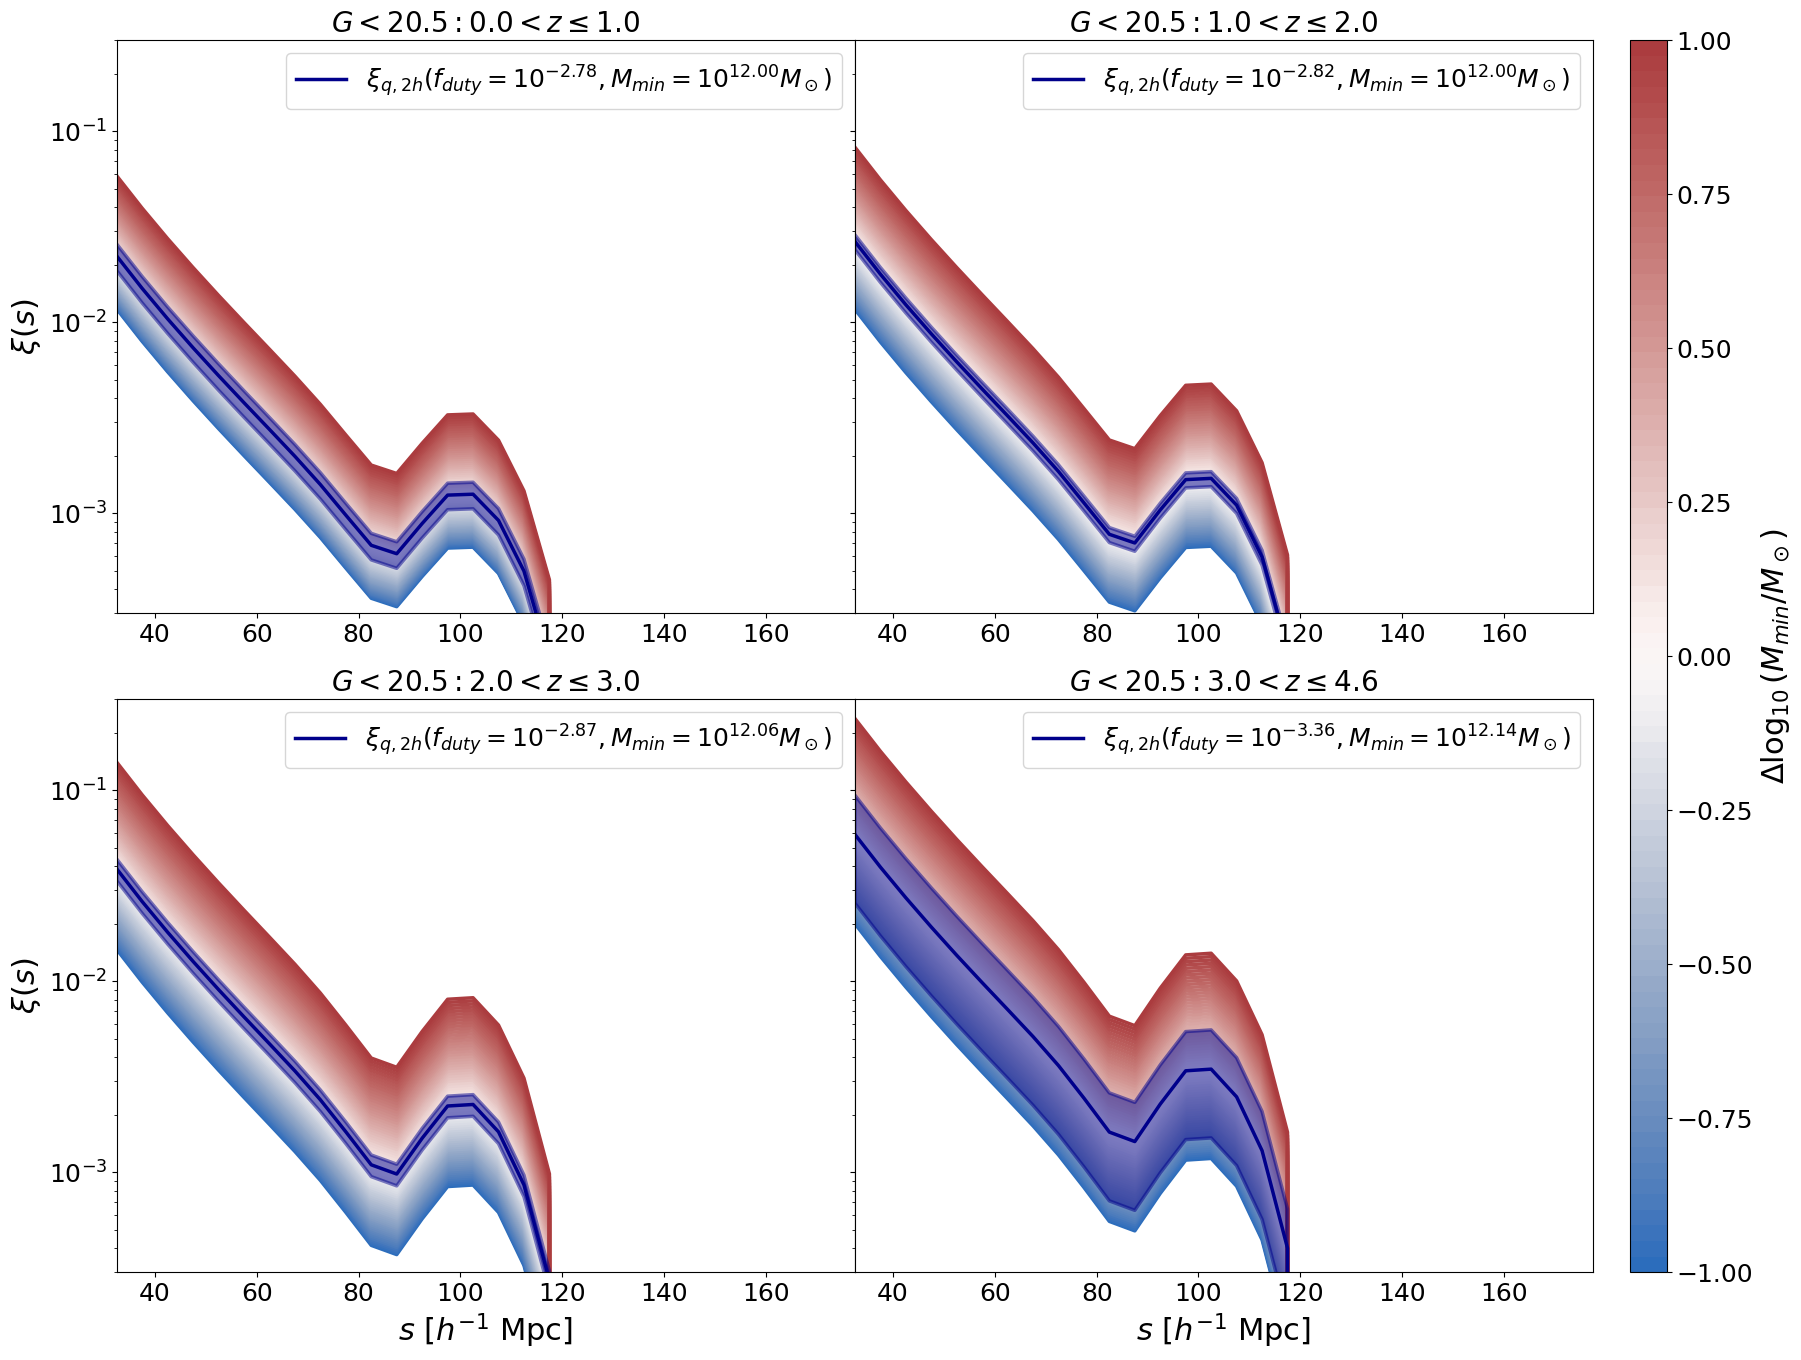

In [78]:
# remove bottom panel and just print bq somewhere
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 4, hspace = 0.15, wspace = 0, width_ratios = [1,1,0.05,0.05])

l = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+l])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
           
    if quaia.recenter(rbins_chi2)[0] < 30:
        ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                          alpha = 0.5, label = 'scales excluded from fit')
        ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                          alpha = 0.5)

    # plot new fit
    n_m=np.ones(np.shape(bins))*f_duty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5,
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = 'darkblue')

    for k in range(len(bins)):
        cf_2h_sample, _ = cf_2h(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), n_m, a_zbin[j], 
                 cosmo_planck18, cf_matter_chi2[j], recenter = False)
        ax1.plot(quaia.recenter(rbins_chi2), cf_2h_sample, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
        
    cf_2h_samples = []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*f_duty_samples[j][i]
        cf_2h_sample, _ = cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                                recenter = False)
        cf_2h_samples.append(cf_2h_sample)
    cf_2h_16, cf_2h_50, cf_2h_84 = np.percentile(cf_2h_samples, [16, 50, 84], axis=0)
    ax1.fill_between(quaia.recenter(rbins_chi2), cf_2h_16, cf_2h_84, linewidth = 2.5, alpha = 0.5,
             color = 'darkblue')    
    
    # if j % 6 < 2:
    ax1.set_title('$G<{}: {:.1f}<z \leq{:.1f}$'.format(G_hi, z_bins[j], z_bins[j+1]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_ylim(3e-4, 3e-1)
    ax1.legend()
    
    if j % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')

    else:
        ax1.set_yticklabels([])

    if j > 1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # 
            
    if j == 1:
        l+=2

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [79]:
b_q_percentile = []
for j in z_array:
    b_q_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        b_q_samples.append(cf_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                                recenter = False)[1])
    b_q_percentile.append(np.percentile(b_q_samples, [16, 84]))
b_q_lo, b_q_hi = np.array(b_q_percentile).T

<>:51: SyntaxWarning: invalid escape sequence '\D'
<>:51: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_103182/2055880083.py:51: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


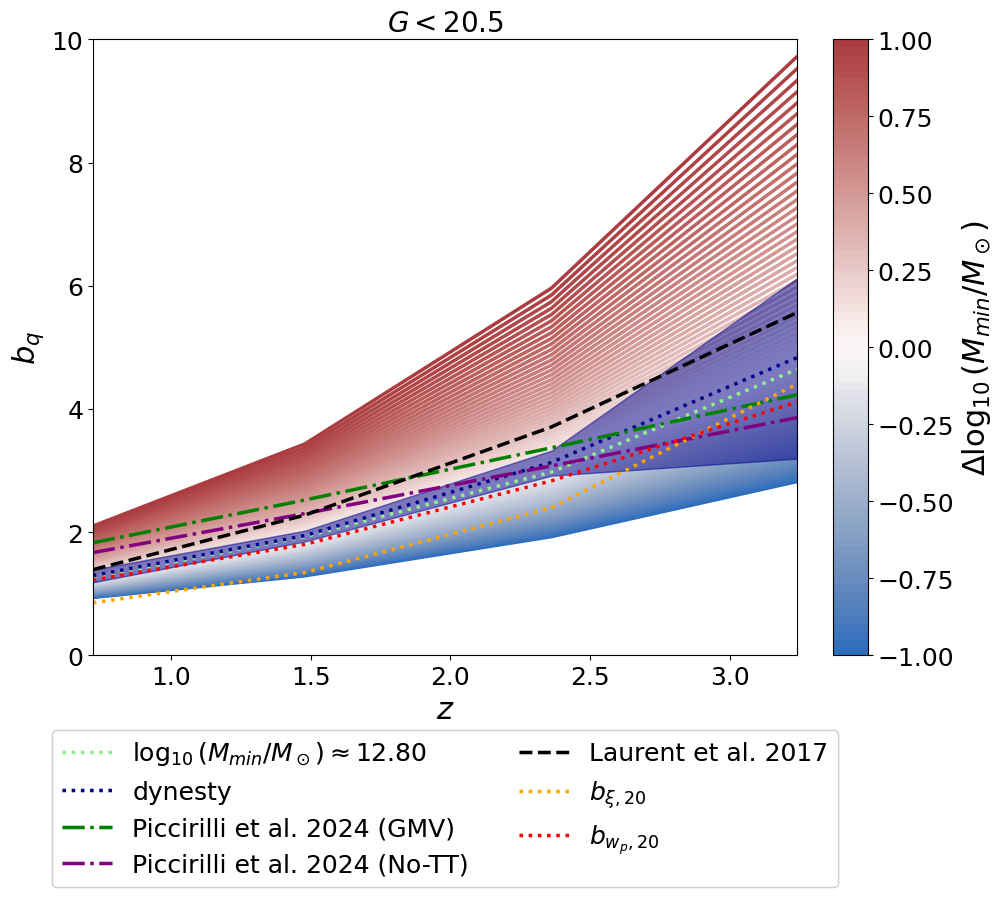

In [80]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
    
b_q = [cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
             recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

b_q = [cf_2h(np.logspace(M_min[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a_zbin[j], cosmo_planck18, 
             cf_matter_chi2[j], recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, b_q_lo, b_q_hi, alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

for k in range(len(bins)):
    b_q = [cf_2h(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*f_duty[j], a_zbin[j], 
                 cosmo_planck18, cf_matter_chi2[j], recenter = False)[1] for j in z_array]
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(zbin, b_quaia(1.26, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_quaia(1.15, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 10)
ax1.set_xlim(zbin[0], zbin[-1])
ax1.set_ylabel(r'$b_q$')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [81]:
M_h_percentile = []
for j in z_array:
    M_h_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        M_h_samples.append(M(np.logspace(M_min_samples[j][i], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0])
    M_h_percentile.append(np.percentile(M_h_samples, [16, 84]))
M_h_lo, M_h_hi = np.array(M_h_percentile).T

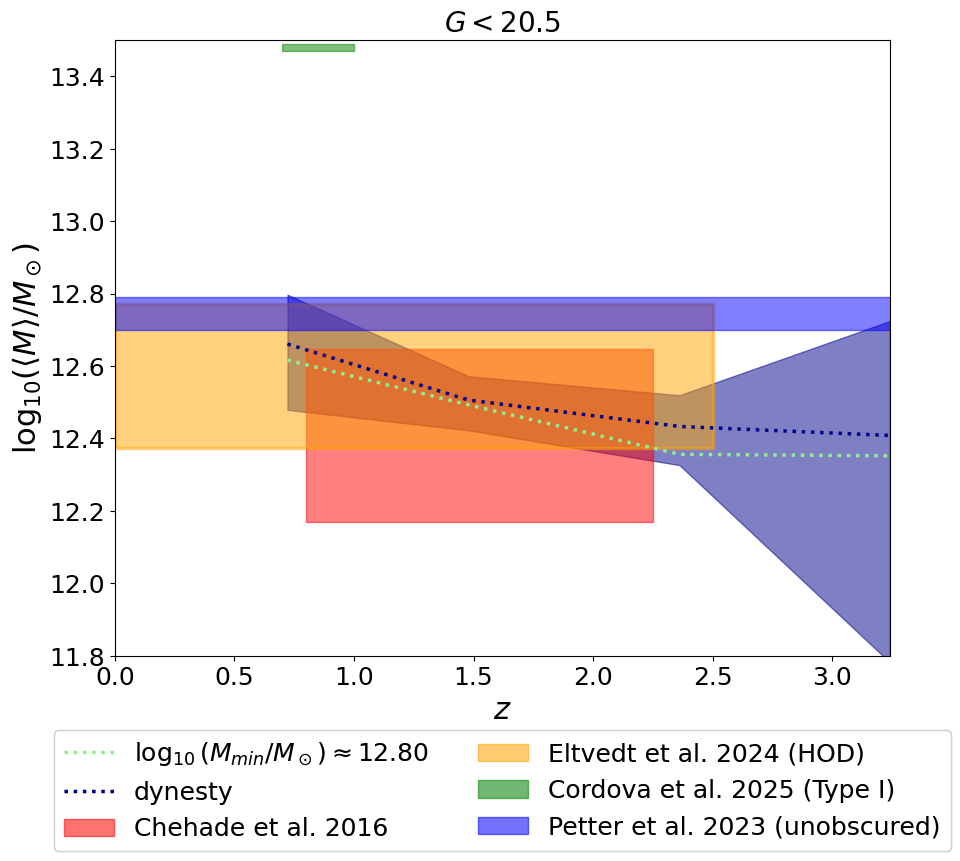

In [82]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

M_h = [M(np.logspace(M_min[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(11.8, 13.5)

plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\D'
<>:46: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_103182/1482196861.py:46: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


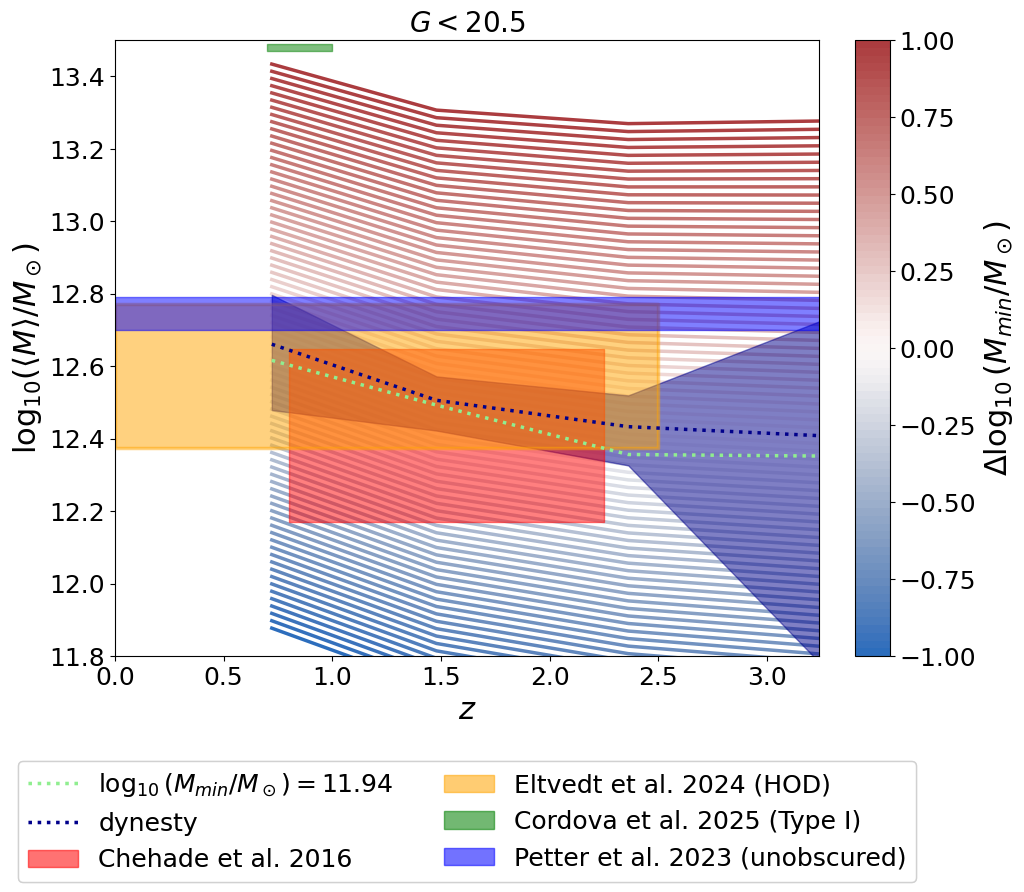

In [83]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    M_h = [M(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, 
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
             color = cmap_M_min[k], zorder = 0) #, alpha = (1+k)/len(bins))
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

M_h = [M(np.logspace(M_min[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0] for j in range(len(z_array))]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), 'dynesty',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.15), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(11.8, 13.5)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [84]:
fduty_array = np.logspace(-5,0, 51) #-4

In [85]:
cmap_fduty_k = sns.color_palette("vlag", n_colors = len(fduty_array))

In [86]:
n_q_percentile = []
for j in z_array:
    n_q_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        n_q_samples.append(M(np.logspace(M_min_samples[j][i], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[1])
    n_q_percentile.append(np.percentile(n_q_samples, [16, 84]))
n_q_theory_fit_lo, n_q_theory_fit_hi = np.array(n_q_percentile).T

<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:76: SyntaxWarning: invalid escape sequence '\D'
<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:76: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_103182/2572909852.py:43: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
/tmp/ipykernel_103182/2572909852.py:76: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(f_{duty})$')


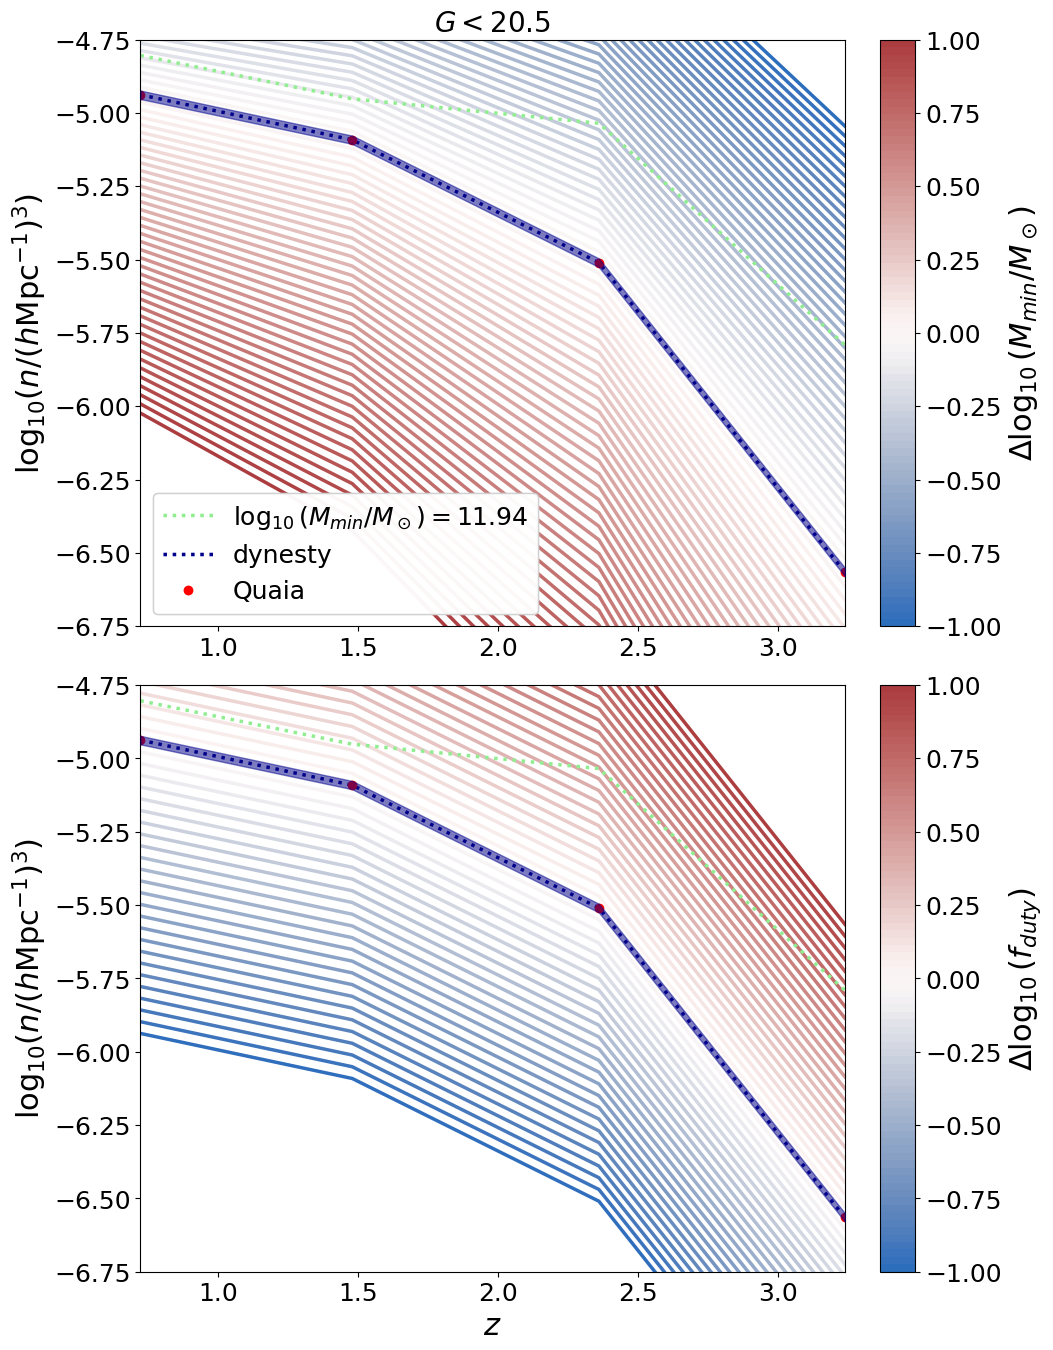

In [87]:
fig = plt.figure(figsize = (10, 16))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(2, 3, width_ratios = [1, 0.05, 0.05], wspace = 0, hspace = 0.1)
ax1 = fig.add_subplot(gs[0])
ylim = -6.75, -4.75

for k in range(len(bins)):
    
    n_q_theory = [M(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(f_duty[0]*100, f_duty[-1]*100, np.log10(bins[0]), 
                                                                                                  np.log10(bins[-1])), color = cmap_M_min[k])
    
n_q_theory, n_q_theory_fit = [], [] #, n_q_theory_fit_lo, n_q_theory_fit_hi = [], [], [], []
for j in z_array:
    
    n_q_theory.append(M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
    
    n_m=np.ones(np.shape(bins))*10**f_duty[j]
    n_q_theory_fit.append(M(np.logspace(M_min[j], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])

ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = 'darkblue', alpha = 0.5, label = r'$\chi^2$ minimization', zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_xlim(zbin[0], zbin[-1])

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5, 
                       label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5, 
                       label = 'dynesty'), 
                Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[0,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')

ax1 = fig.add_subplot(gs[3])
i = 1
l = 38

for k in range(len(fduty_array)):

    n_q_theory=[]
    for j in z_array:
        
        n_m = np.ones(np.shape(bins))*10**(f_duty[j]-1+k/int(len(fduty_array)/2))
        n_q_theory.append(M(np.logspace(M_min[j], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
        
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             color = cmap_fduty_k[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])) # color = cmaps[i][j], alpha = (l+1)/len(bins)) np.log10(bins[l])

ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'dynesty') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = 'darkblue', alpha = 0.5, zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)
ax1.set_xlim(zbin[0], zbin[-1])

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[1,-1]), 
                    label = '$\Delta \log_{10}(f_{duty})$')
plt.show()

# Debug covariance
## Plot the amplitude of the diagonal of the covariance

In [137]:
N_jk = [15, 20, 30, 40, 50, 65]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(N_jk)))

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_53835/4211568612.py:21: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_ylabel('$\sigma$')
/tmp/ipykernel_53835/4211568612.py:26: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))


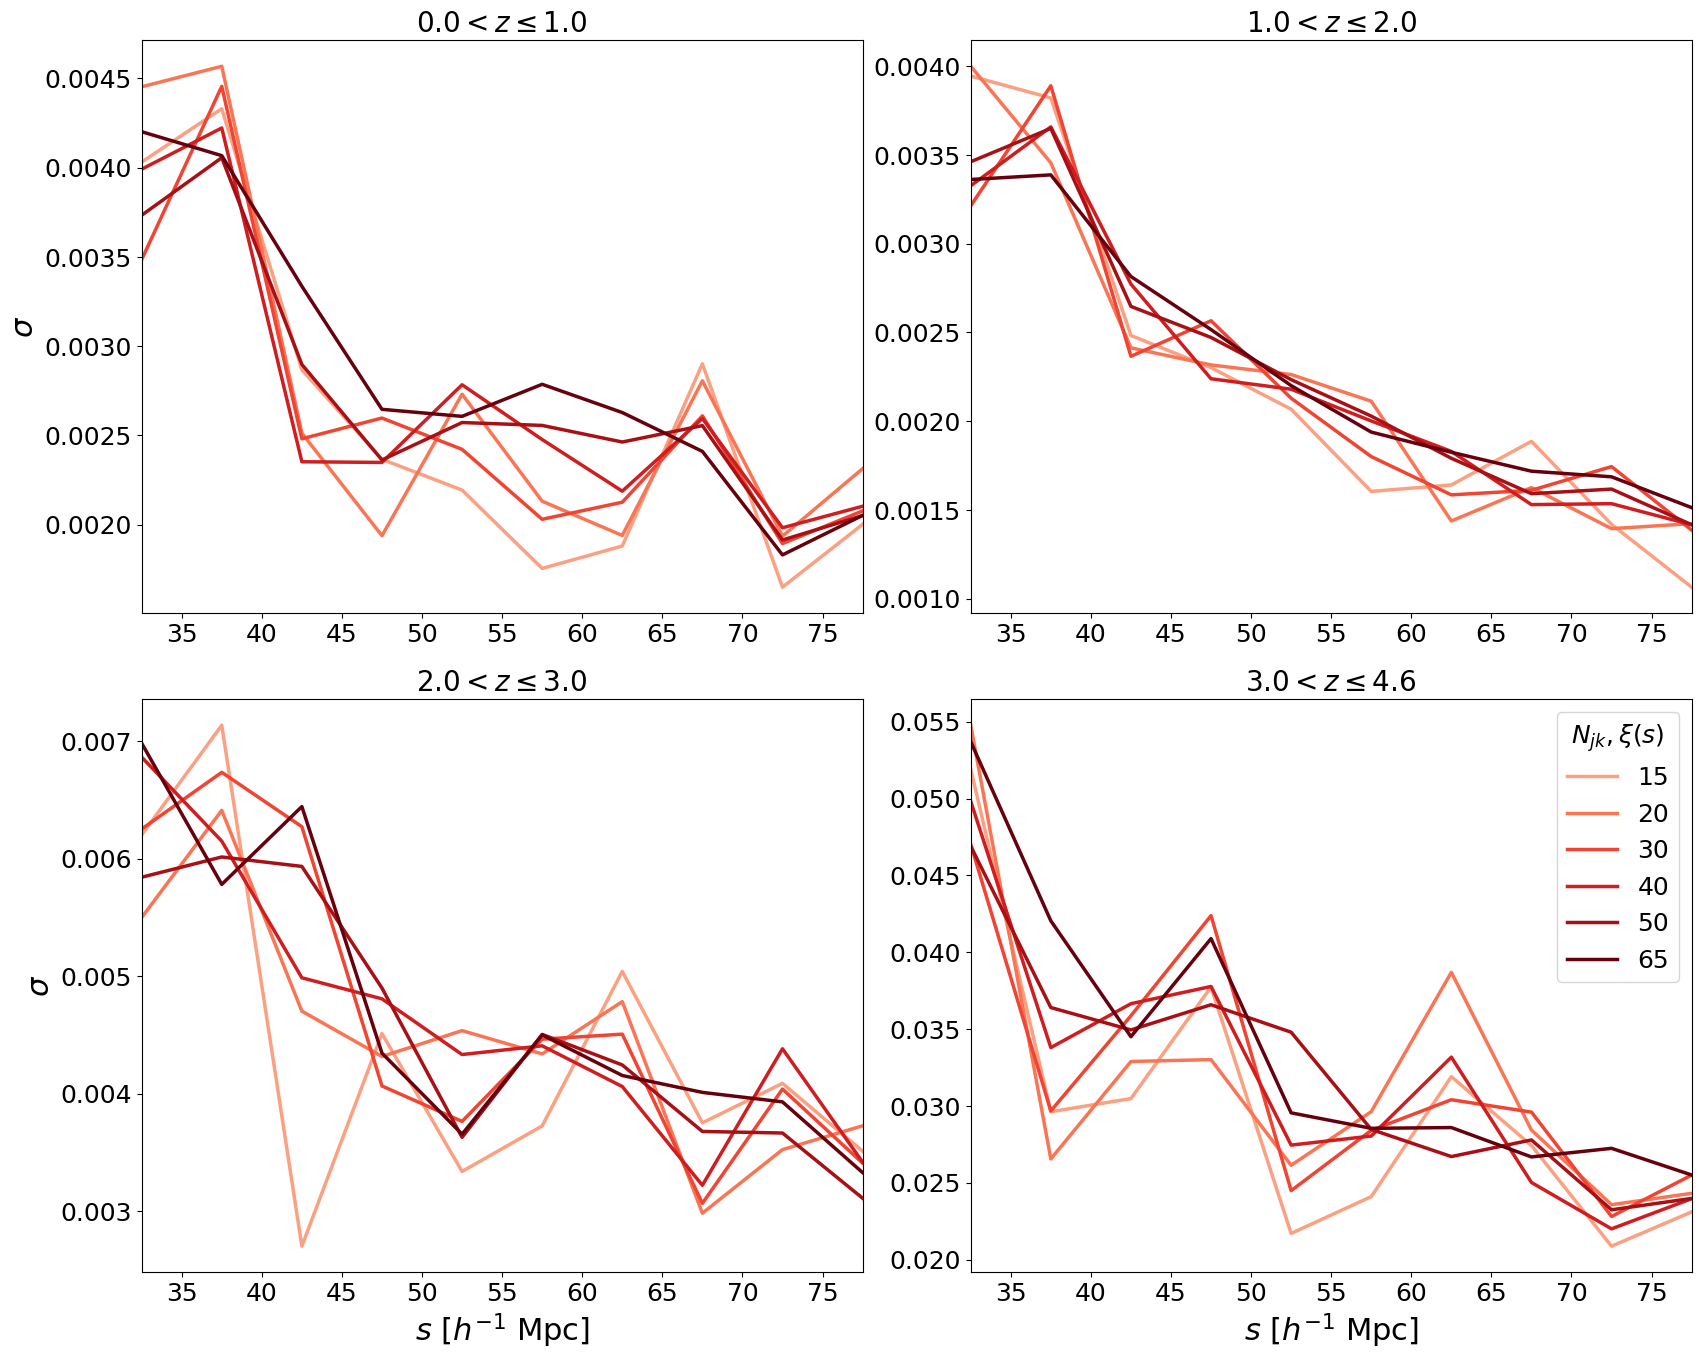

In [138]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0.15)

for j in z_array:

    ax1 = fig.add_subplot(gs[j])

    for i in range(len(N_jk)):
        
        C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], 
                                                                                                             z_bins[j+1], N_jk[i], cosmo)) # good
    
        ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(np.diag(C)), linewidth = 2.5, label = N_jk[i], color = cmap_red[i])    
        ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
        # ax1.set_yscale('log')
    
        if j > 1:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') #
                
        if j %2 ==0:
            ax1.set_ylabel('$\sigma$')
        # else:
        #     ax1.set_yticklabels([])
    
        # ax1.set_ylim(1e-3, 6e-2)
        ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))

ax1.legend(title = r'$N_{jk},\xi(s)$', title_fontsize = 18)
    
plt.show()

## Plot the condition number

In [139]:
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(z_array)))

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_53835/173630722.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(N_jk, cond, linewidth = 2.5, label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), color = cmap_blue[j])


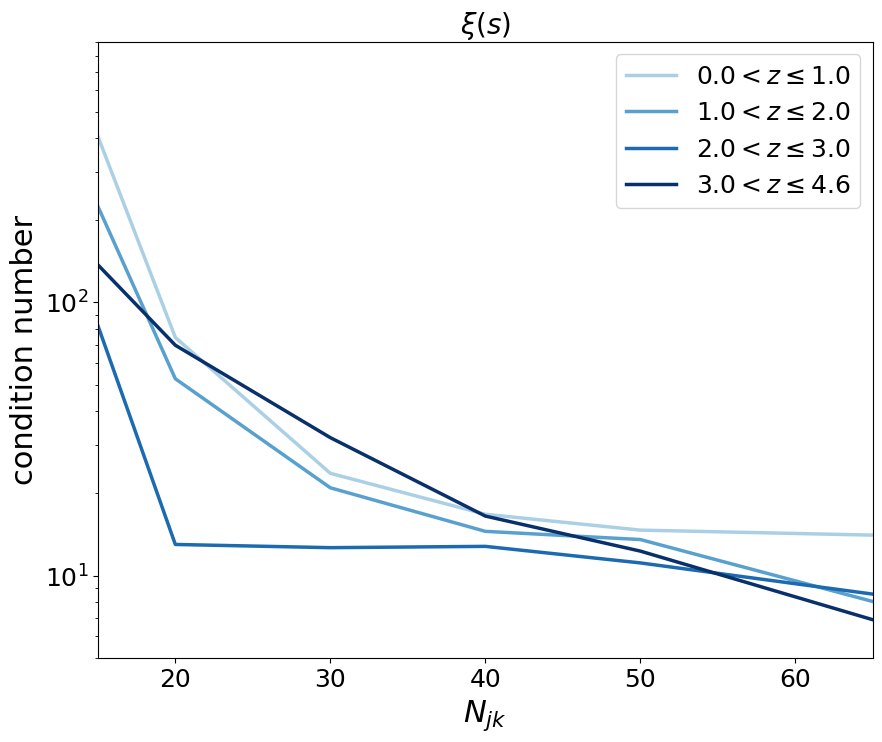

In [140]:
fig = plt.figure(figsize = (10, 8))
gs = gridspec.GridSpec(1, 1, hspace = 0.15, wspace = 0)

ax1 = fig.add_subplot(gs[0])
for j in z_array:

    # ax1 = fig.add_subplot(gs[j])

    cond = []
    for i in range(len(N_jk)):
        
        C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], 
                                                                                                             z_bins[j+1], N_jk[i], cosmo)) # good

        cond.append(np.linalg.cond(C))

    ax1.plot(N_jk, cond, linewidth = 2.5, label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), color = cmap_blue[j])    
    
ax1.set_yscale('log')
ax1.set_xlim(N_jk[0], N_jk[-1])

# if j > 1:
ax1.set_xlabel(r'$N_{jk}$') #
        
# if j %2 ==0:
ax1.set_ylabel('condition number')
# else:
#     ax1.set_yticklabels([])

ax1.set_ylim(5, 9e2)
ax1.set_title(r'$\xi(s)$')

ax1.legend()
plt.show()

<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:29: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_53835/1363878191.py:29: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))


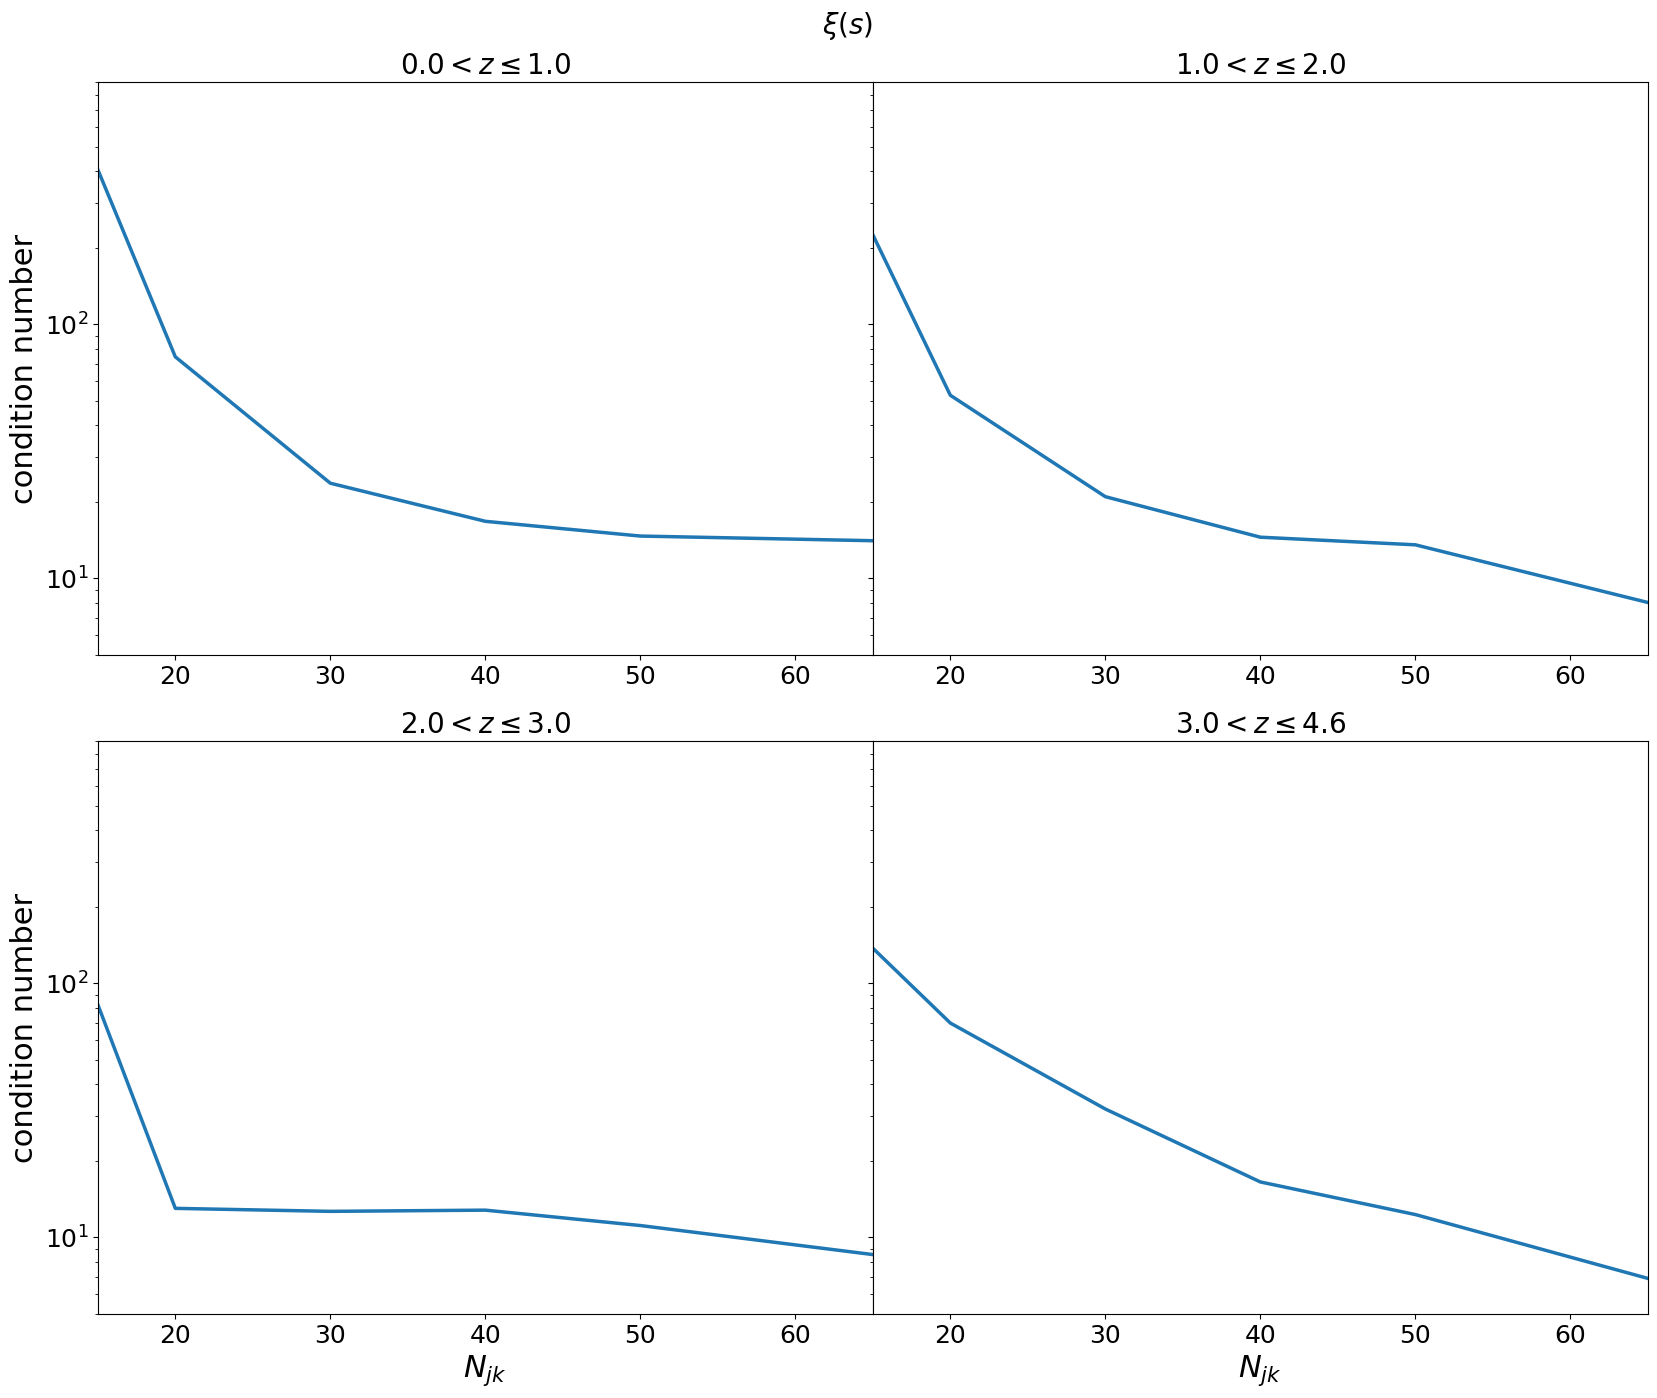

In [141]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)

for j in z_array:

    ax1 = fig.add_subplot(gs[j])

    cond = []
    for i in range(len(N_jk)):
        
        C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], 
                                                                                                             z_bins[j+1], N_jk[i], cosmo)) # good

        cond.append(np.linalg.cond(C))

    ax1.plot(N_jk, cond, linewidth = 2.5)    
    ax1.set_yscale('log')
    ax1.set_xlim(N_jk[0], N_jk[-1])

    if j > 1:
        ax1.set_xlabel(r'$N_{jk}$') #
            
    if j %2 ==0:
        ax1.set_ylabel('condition number')
    else:
        ax1.set_yticklabels([])

    ax1.set_ylim(5, 9e2)
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))

plt.suptitle(r'$\xi(s)$', fontsize = 20, y = 0.925)
plt.show()